# After EDA and Data Cleaning and Preprocessing is done now we again check EDA

### Datasets:
1. Tiny ImageNet,
2. ImageNet-21K Winter21,
3. ImageNet-21K-P Winter21

## Imports

In [1]:
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.dataset.imagenet21k_p_dataset import ImageNet21KPLoader

from src.eda.dataset_structure import dataset_summary, train_test_split_analysis
from src.eda.class_analysis import class_analysis, images_per_class_analysis, class_distribution_analysis
import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset

import importlib
importlib.reload(model_ready_dataset)

<module 'src.data_cleaning_and_preprocessing._model_ready_dataset' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/_model_ready_dataset.py'>

## Load Dataset

In [2]:
tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(
        seed=42
    )
).load()

In [3]:
imagenet_21k_p = model_ready_dataset.ModelReadyDatasetLoader(
    ImageNet21KPLoader(
        mode="sample",
        sample_classes=200,
        train_images_per_class=None,
        seed=42,
    )
).load()


ImageNet-21K-P Winter21 Sample
-------------------------------------------------------
Classes               : 200
Train images/class    : ALL
Expected train        : depends on selected classes
Validation/class      : 50
Expected validation   : 10,000
Output folder         : data/imagenet21k_p/images
-------------------------------------------------------


Building ImageNet-21K-P sample:   0%|          | 0/200 [00:00<?, ?class/s]

In [4]:
dataset_list = [
    tiny_imagenet,
    imagenet_21k_p,
]

## A. Dataset Structure

#### 1. Dataset Overview / Summary

In [5]:
overview = dataset_summary.dataset_overview(dataset_list=dataset_list)
overview

,Dataset,Train Images,Validation Images,Test Images,Total Images,Number of Classes
0,tiny_imagenet,99953,9993,9988,119934,200
1,imagenet21k_p,201319,4958,4977,211254,200


#### 2. Train, Validation and Test Split Analysis

In [6]:
split_analysis = train_test_split_analysis.dataset_split_analysis(dataset_list=dataset_list)

split_analysis

,Dataset,Train Images,Train %,Validation Images,Validation %,Test Images,Test %,Total Images
0,tiny_imagenet,99953,83.34,9993,8.33,9988,8.33,119934
1,imagenet21k_p,201319,95.30,4958,2.35,4977,2.36,211254


## B. Class Analysis

#### 3. Number of Classes / Class-Synset Mapping Analysis

In [7]:
_, class_mappings = class_analysis.class_synset_analysis(dataset_list=dataset_list)

In [8]:
class_mappings["tiny_imagenet"].head(10)

,Class Index,Class / Synset ID,Class Name
0,0,n01443537,"[goldfish, Carassius auratus]"
1,1,n01629819,"[European fire salamander, Salamandra salaman..."
2,2,n01641577,"[bullfrog, Rana catesbeiana]"
3,3,n01644900,"[tailed frog, bell toad, ribbed toad, taile..."
4,4,n01698640,"[American alligator, Alligator mississipiensis]"
5,5,n01742172,"[boa constrictor, Constrictor constrictor]"
6,6,n01768244,[trilobite]
7,7,n01770393,[scorpion]
8,8,n01774384,"[black widow, Latrodectus mactans]"
9,9,n01774750,[tarantula]


In [9]:
class_mappings["imagenet21k_p"].head(10)

,Class Index,Class / Synset ID,Class Name
0,0,n00288000,dressage
1,1,n00448748,figure_skating
2,2,n00468480,football
3,3,n01339801,cytomegalovirus
4,4,n01535690,white-crowned_sparrow
5,5,n01543632,Java_sparrow
6,6,n01568294,American_redstart
7,7,n01574801,rusty_blackbird
8,8,n01593028,bushtit
9,9,n01605630,hawk


#### 4. Images per Class Analysis

In [10]:
images_per_class, class_counts = images_per_class_analysis.images_per_class_analysis(dataset_list=dataset_list)

images_per_class

,Dataset,Split,Label Status,Total Images,Classes,Min Images/Class,Max Images/Class,Mean Images/Class,Median Images/Class,Std Images/Class
0,tiny_imagenet,Train,Labelled,99953,200,495,500,499.76,500.0,0.74
1,tiny_imagenet,Validation,Labelled,9993,200,48,50,49.96,50.0,0.21
2,tiny_imagenet,Test,Unlabelled,9988,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,201319,200,435,2413,1006.6,1052.5,340.15
4,imagenet21k_p,Validation,Labelled,4958,200,13,25,24.79,25.0,1.04
5,imagenet21k_p,Test,Labelled,4977,200,18,25,24.88,25.0,0.63


#### 5. Class Distribution and Class Imbalance Analysis

In [11]:
class_distribution, class_distribution_details = class_distribution_analysis.class_distribution_analysis(
    dataset_list=dataset_list)

class_distribution

,Dataset,Split,Label Status,Total Images,Classes,Min Images/Class,Max Images/Class,Mean Images/Class,Median Images/Class,Std Images/Class,Imbalance Ratio,Coefficient of Variation,Distribution Status
0,tiny_imagenet,Train,Labelled,99953,200,495,500,499.76,500.0,0.74,1.01,0.001,Imbalanced
1,tiny_imagenet,Validation,Labelled,9993,200,48,50,49.96,50.0,0.21,1.042,0.004,Imbalanced
2,tiny_imagenet,Test,Unlabelled,9988,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,201319,200,435,2413,1006.6,1052.5,340.15,5.547,0.338,Imbalanced
4,imagenet21k_p,Validation,Labelled,4958,200,13,25,24.79,25.0,1.04,1.923,0.042,Imbalanced
5,imagenet21k_p,Test,Labelled,4977,200,18,25,24.88,25.0,0.63,1.389,0.025,Imbalanced


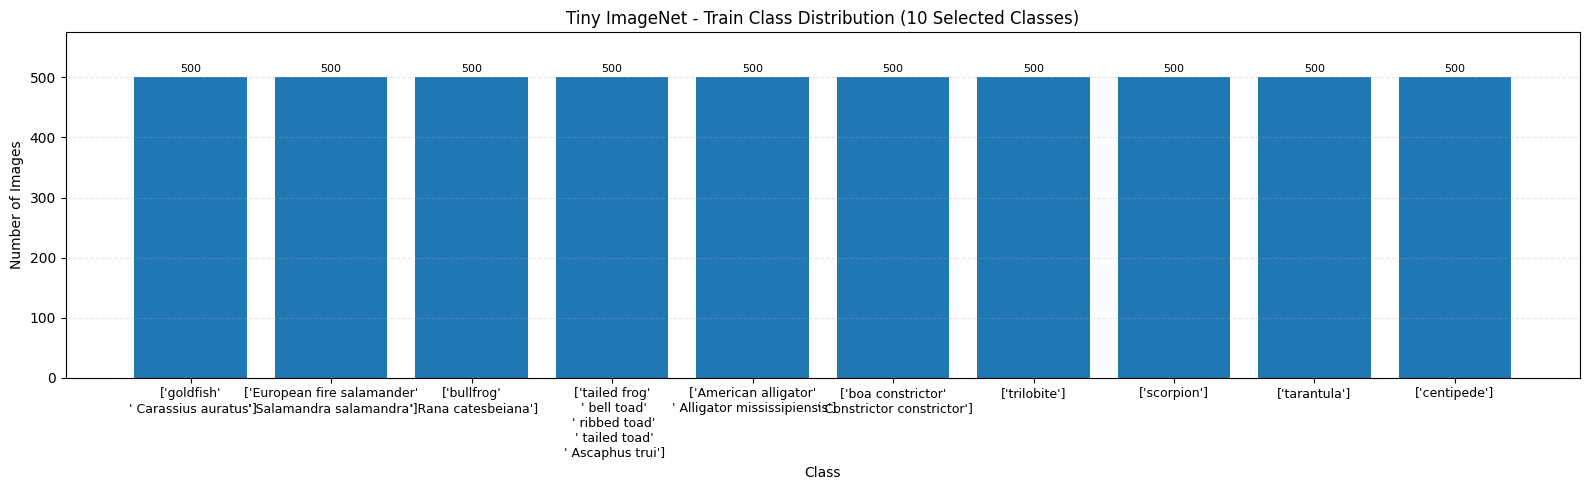

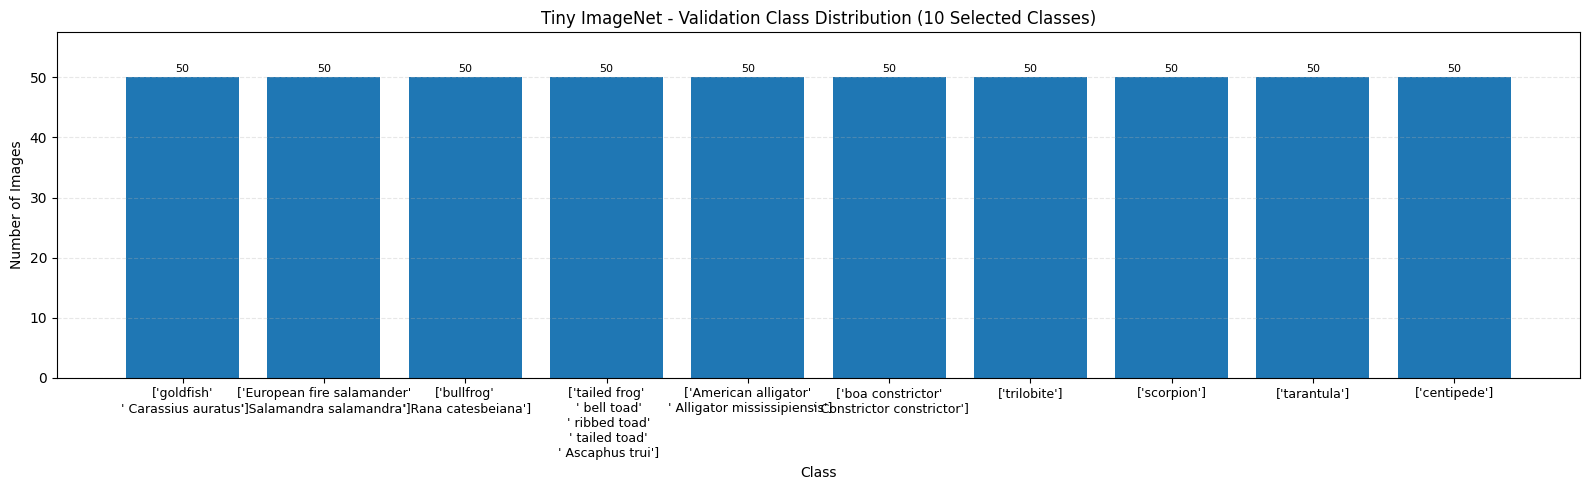

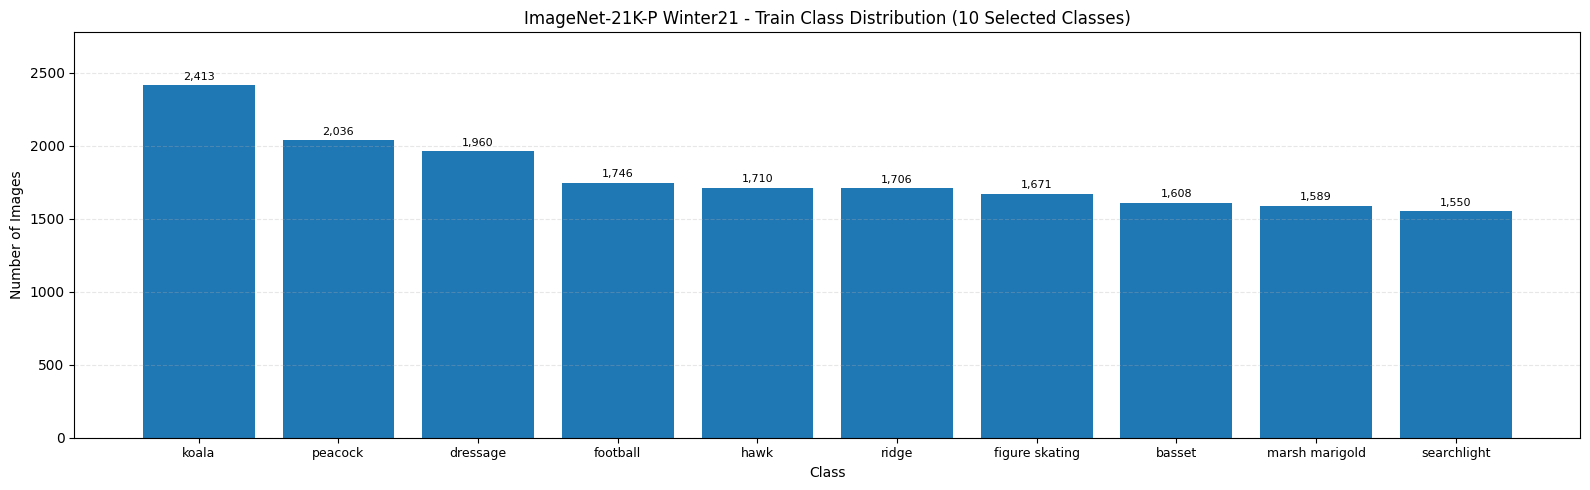

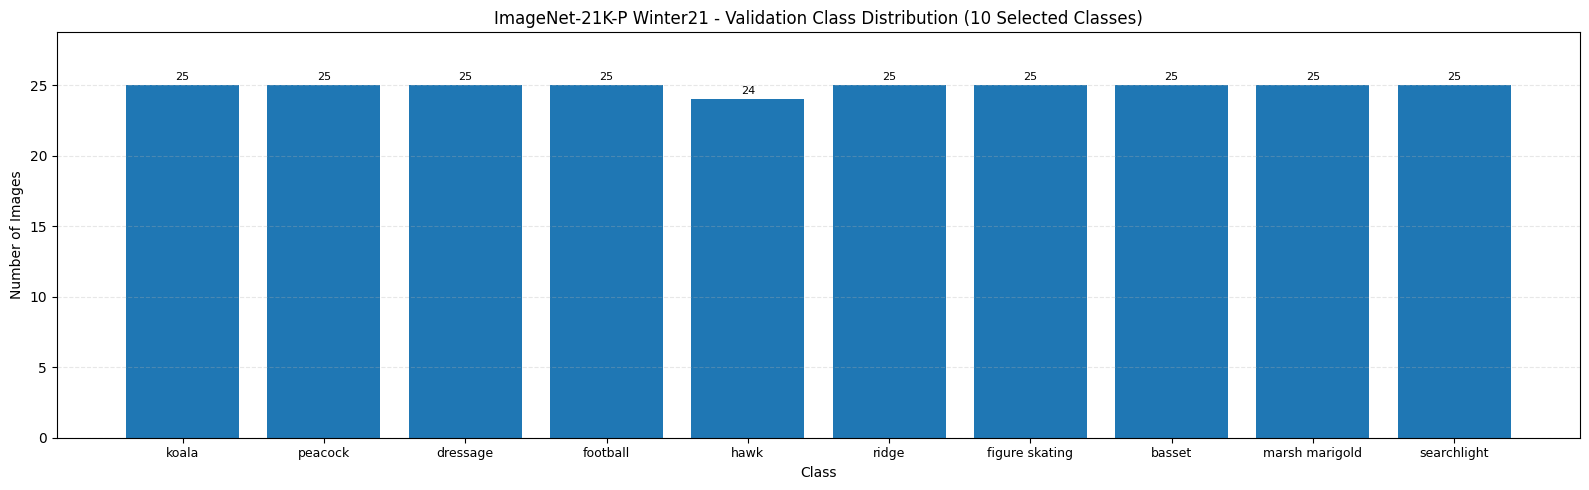

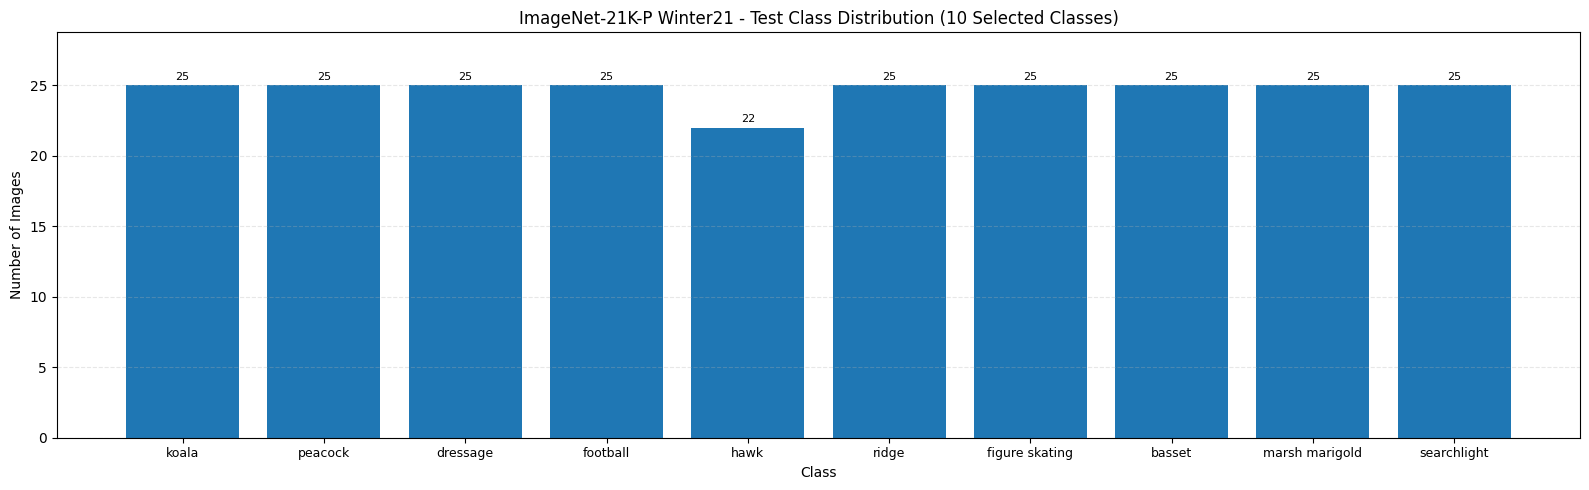

In [12]:
class_distribution_analysis.plot_class_distribution(
    class_distribution_details,
    sample_n=10
)

#### 6. Class Coverage Across Splits

In [13]:
import src.eda.class_analysis.class_coverage_analysis as class_coverage_analysis

class_coverage, class_coverage_details = (
    class_coverage_analysis.class_coverage_analysis(dataset_list=dataset_list)
)

class_coverage

,Dataset,Train Classes,Validation Classes,Test Classes,Validation Coverage (%),Test Coverage (%),All Labelled Splits Coverage (%),Missing in Validation,Missing in Test,Extra in Validation,Extra in Test,Coverage Status
0,tiny_imagenet,200,200,N/A,100.0,N/A,100.0,0,N/A,0,N/A,Complete for Labelled Splits
1,imagenet21k_p,200,200,200,100.0,100.0,100.0,0,0,0,0,Complete


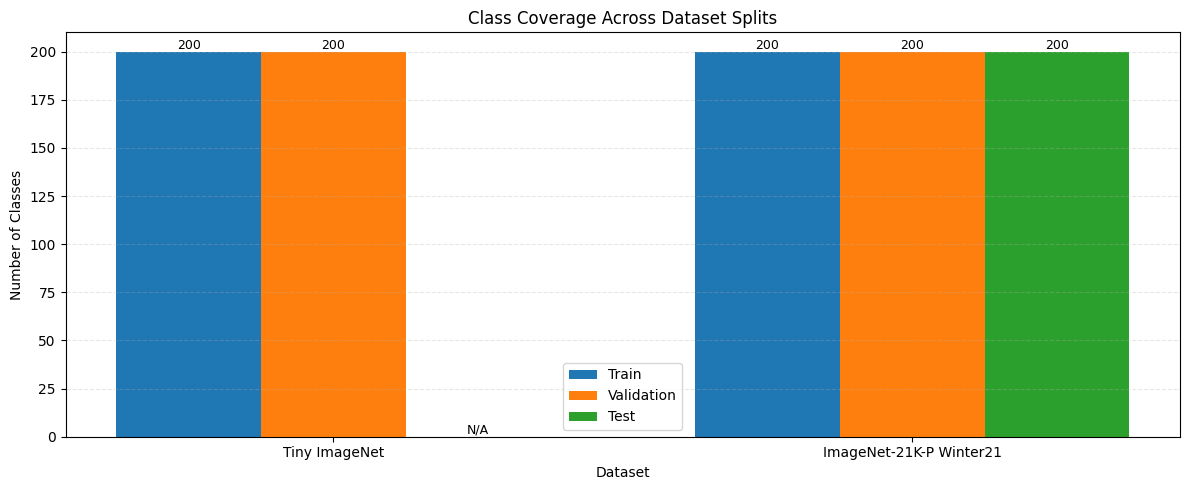

In [14]:
class_coverage_analysis.plot_class_coverage(
    class_coverage
)

## C. Image Properties

#### 7. Image Dimensions Analysis

In [15]:
import src.eda.image_properties.image_dimensions_analysis as image_dimensions_analysis

image_dimensions, image_dimension_details = (
    image_dimensions_analysis.image_dimensions_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_dimensions

  0%|          | 0/2 [00:00<?, ?it/s]

42:tiny_imagenet:Train
42:tiny_imagenet:Validation
42:tiny_imagenet:Test


 50%|█████     | 1/2 [00:41<00:41, 41.20s/it]

42:imagenet21k_p:Train
42:imagenet21k_p:Validation
42:imagenet21k_p:Test


100%|██████████| 2/2 [07:50<00:00, 235.16s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Min Width,Max Width,Mean Width,Median Width,Min Height,Max Height,Mean Height,Median Height,Unique Resolutions
0,tiny_imagenet,Train,99953,99953,0,224,224,224.0,224.0,224,224,224.0,224.0,1
1,tiny_imagenet,Validation,9993,9993,0,224,224,224.0,224.0,224,224,224.0,224.0,1
2,tiny_imagenet,Test,9988,9988,0,224,224,224.0,224.0,224,224,224.0,224.0,1
3,imagenet21k_p,Train,201319,201319,0,224,224,224.0,224.0,224,224,224.0,224.0,1
4,imagenet21k_p,Validation,4958,4958,0,224,224,224.0,224.0,224,224,224.0,224.0,1
5,imagenet21k_p,Test,4977,4977,0,224,224,224.0,224.0,224,224,224.0,224.0,1


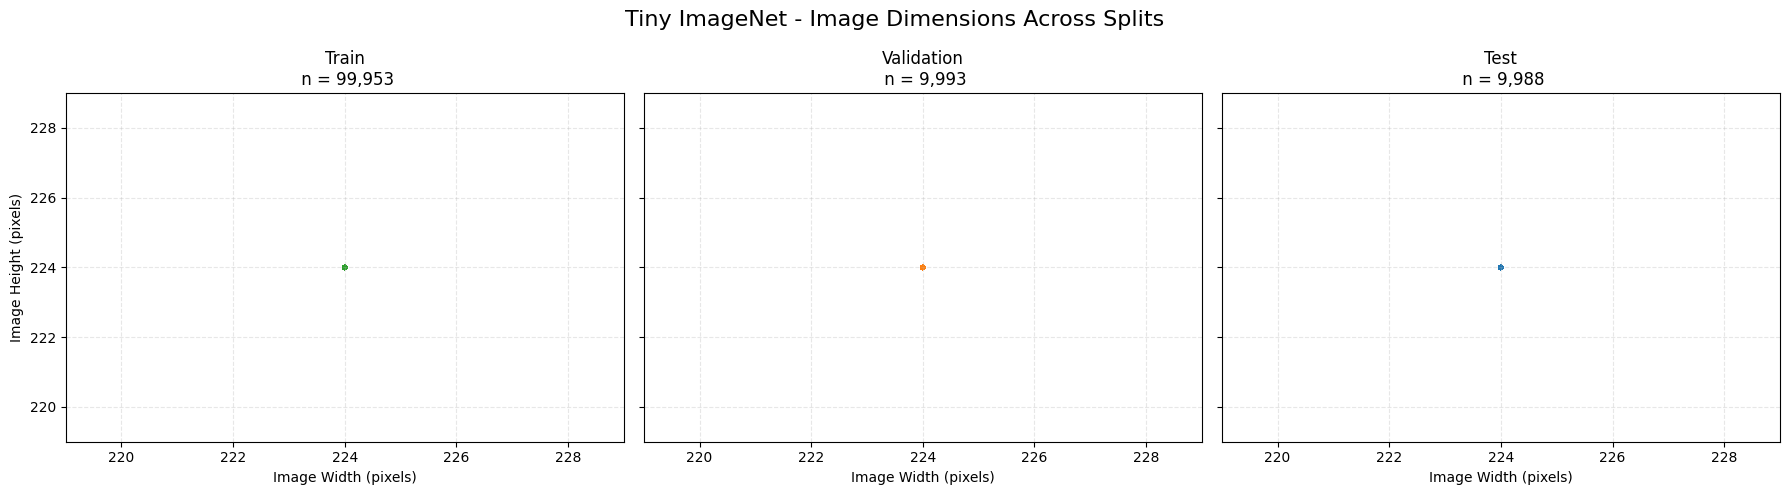

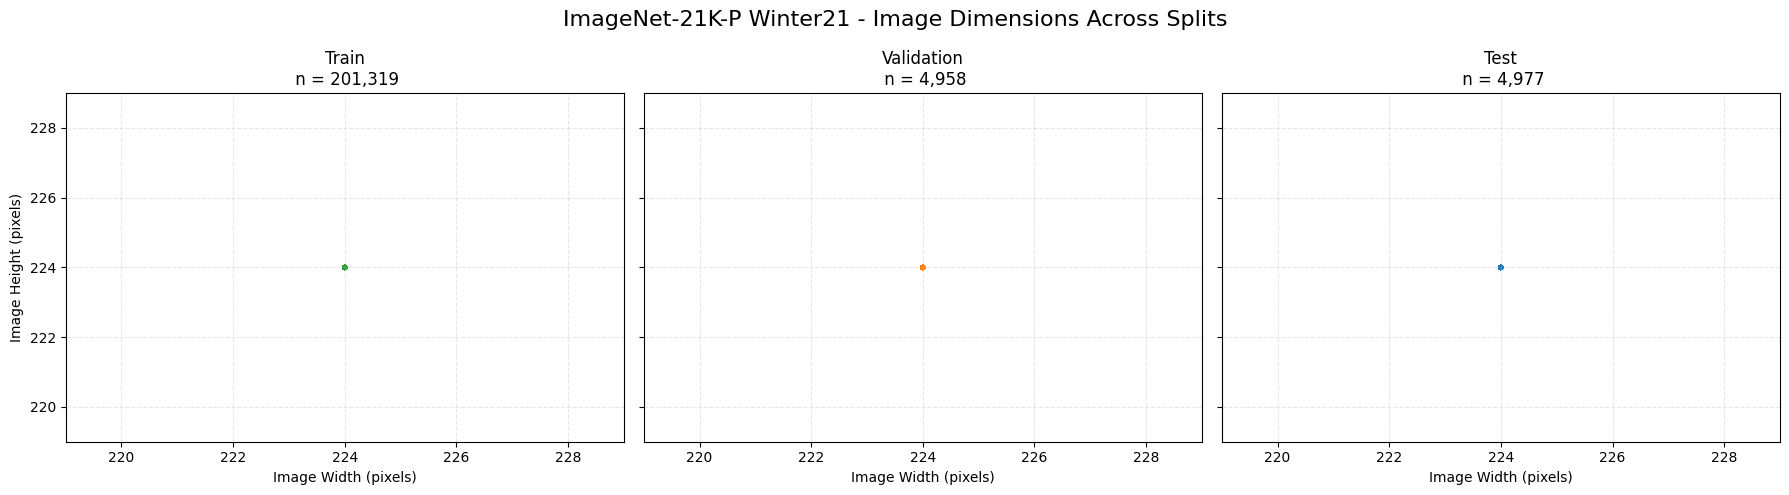

In [16]:
image_dimensions_analysis.plot_image_dimensions(
    image_dimension_details
)

#### 8. Aspect Ratio Distribution

In [17]:
import src.eda.image_properties.aspect_ratio_analysis as aspect_ratio_analysis

aspect_ratio, aspect_ratio_details = (
    aspect_ratio_analysis.aspect_ratio_analysis(
        image_dimension_details
    )
)

aspect_ratio

100%|██████████| 3/3 [00:00<00:00, 105.00it/s]


,Dataset,Split,Analyzed Images,Min Aspect Ratio,Max Aspect Ratio,Mean Aspect Ratio,Median Aspect Ratio,Std Aspect Ratio,Portrait (%),Near Square (%),Landscape (%)
0,tiny_imagenet,Train,99953,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0
1,tiny_imagenet,Validation,9993,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0
2,tiny_imagenet,Test,9988,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0
3,imagenet21k_p,Train,201319,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0
4,imagenet21k_p,Validation,4958,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0
5,imagenet21k_p,Test,4977,1.0,1.0,1.0,1.0,0.0,0.0,100.0,0.0


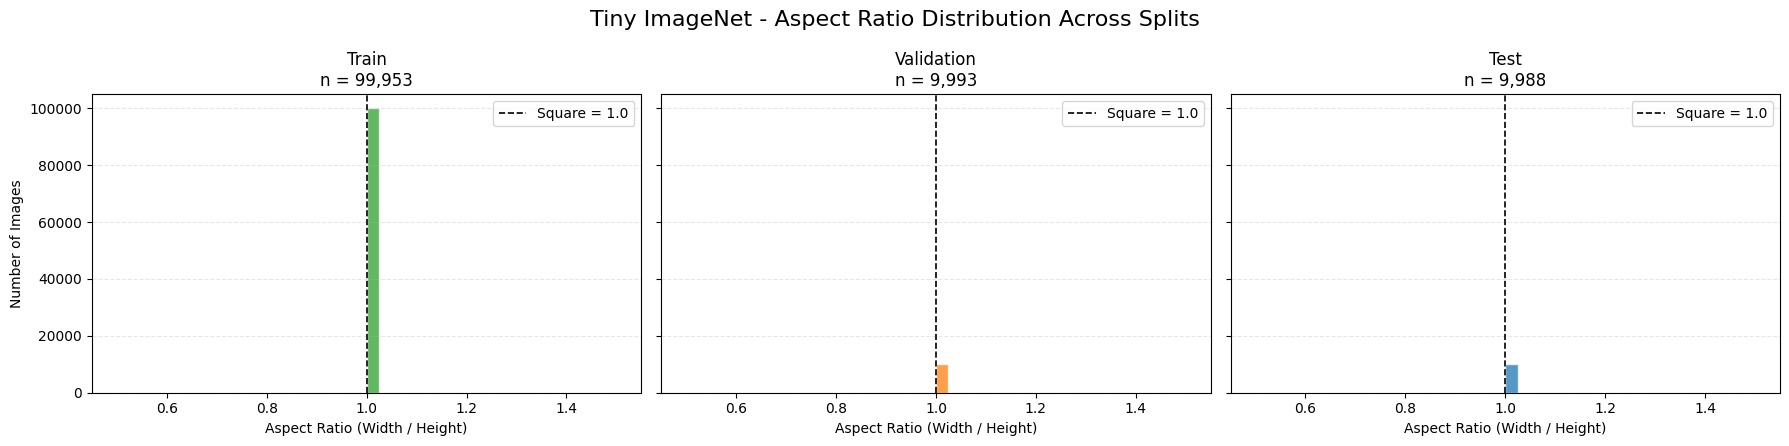

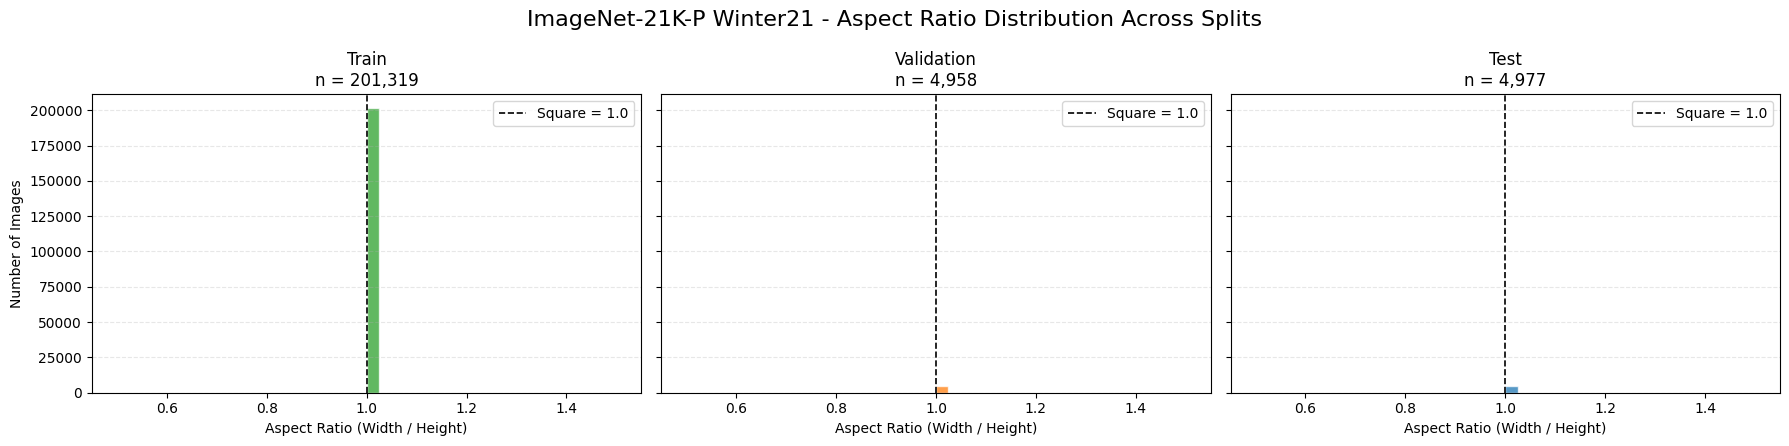

In [18]:
aspect_ratio_analysis.plot_aspect_ratio_distribution(
    aspect_ratio_details
)

#### 9. Image Mode / Channel Analysis

In [19]:
import src.eda.image_properties.image_mode_channel_analysis as image_mode_channel_analysis

image_modes, image_mode_details = (
    image_mode_channel_analysis.image_mode_channel_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_modes

100%|██████████| 3/3 [07:13<00:00, 144.66s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Unique Modes,Most Common Mode,RGB (%),Grayscale (%),RGBA (%),Other (%)
0,tiny_imagenet,Train,99953,99953,0,1,RGB,100.0,0.0,0.0,0.0
1,tiny_imagenet,Validation,9993,9993,0,1,RGB,100.0,0.0,0.0,0.0
2,tiny_imagenet,Test,9988,9988,0,1,RGB,100.0,0.0,0.0,0.0
3,imagenet21k_p,Train,201319,201319,0,1,RGB,100.0,0.0,0.0,0.0
4,imagenet21k_p,Validation,4958,4958,0,1,RGB,100.0,0.0,0.0,0.0
5,imagenet21k_p,Test,4977,4977,0,1,RGB,100.0,0.0,0.0,0.0


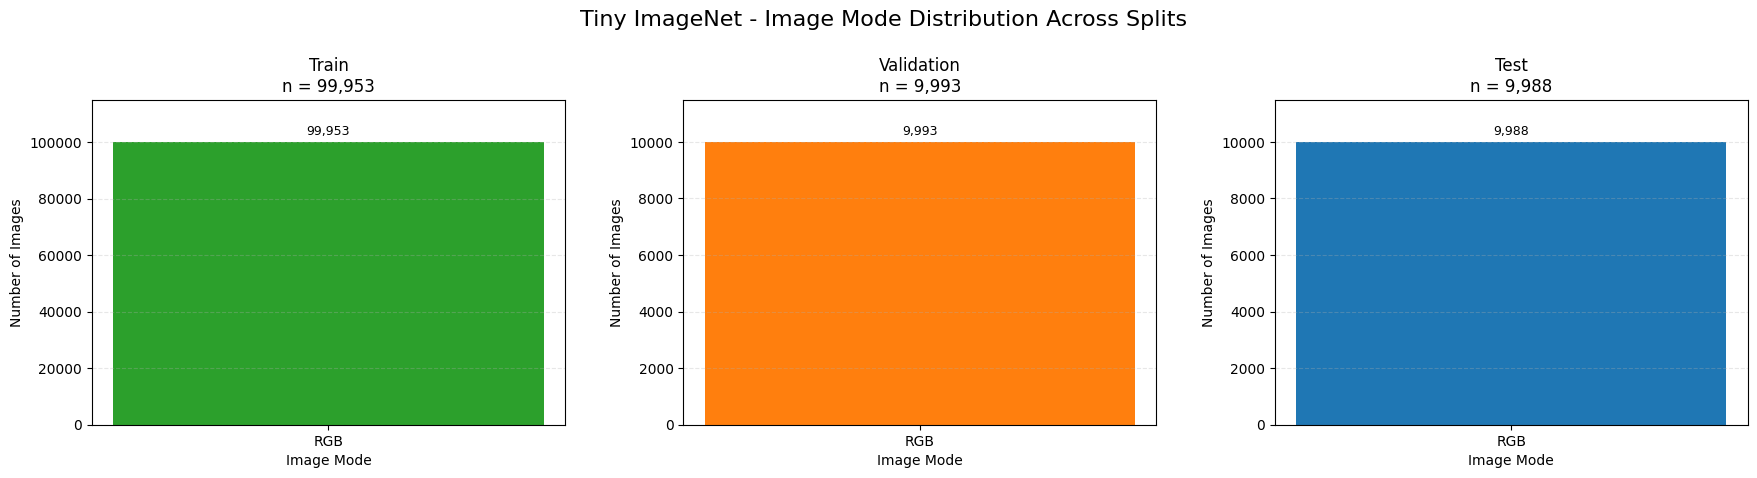

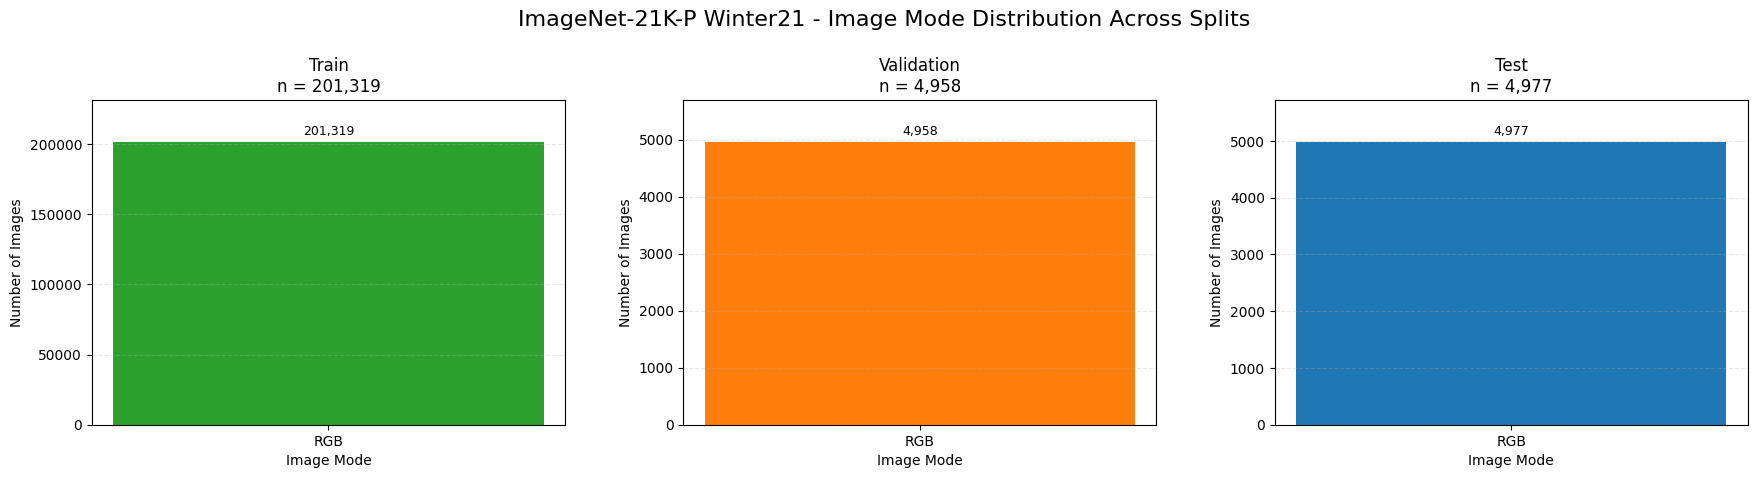

In [20]:
image_mode_channel_analysis.plot_image_modes(
    image_mode_details
)

#### 10. RGB Mean and Standard Deviation

In [21]:
import src.eda.image_properties.rgb_mean_std_analysis as rgb_mean_std_analysis

rgb_stats = rgb_mean_std_analysis.rgb_mean_std_analysis(
    dataset_list=dataset_list,
    max_images=None,
    seed=42,
)

rgb_stats

100%|██████████| 3/3 [08:23<00:00, 167.87s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Mean R,Mean G,Mean B,Std R,Std G,Std B
0,tiny_imagenet,Train,99953,99953,0,-0.0036,-0.0036,-0.0032,0.0698,0.0688,0.0630
1,tiny_imagenet,Validation,9993,9993,0,-0.0031,-0.0033,-0.0030,0.0658,0.0653,0.0598
2,tiny_imagenet,Test,9988,9988,0,-0.0030,-0.0026,-0.0023,0.0615,0.0569,0.0512
3,imagenet21k_p,Train,201319,201319,0,-0.0032,-0.0030,-0.0027,0.0684,0.0669,0.0639
4,imagenet21k_p,Validation,4958,4958,0,-0.0036,-0.0032,-0.0027,0.0697,0.0662,0.0630
5,imagenet21k_p,Test,4977,4977,0,-0.0026,-0.0028,-0.0025,0.0633,0.0620,0.0599


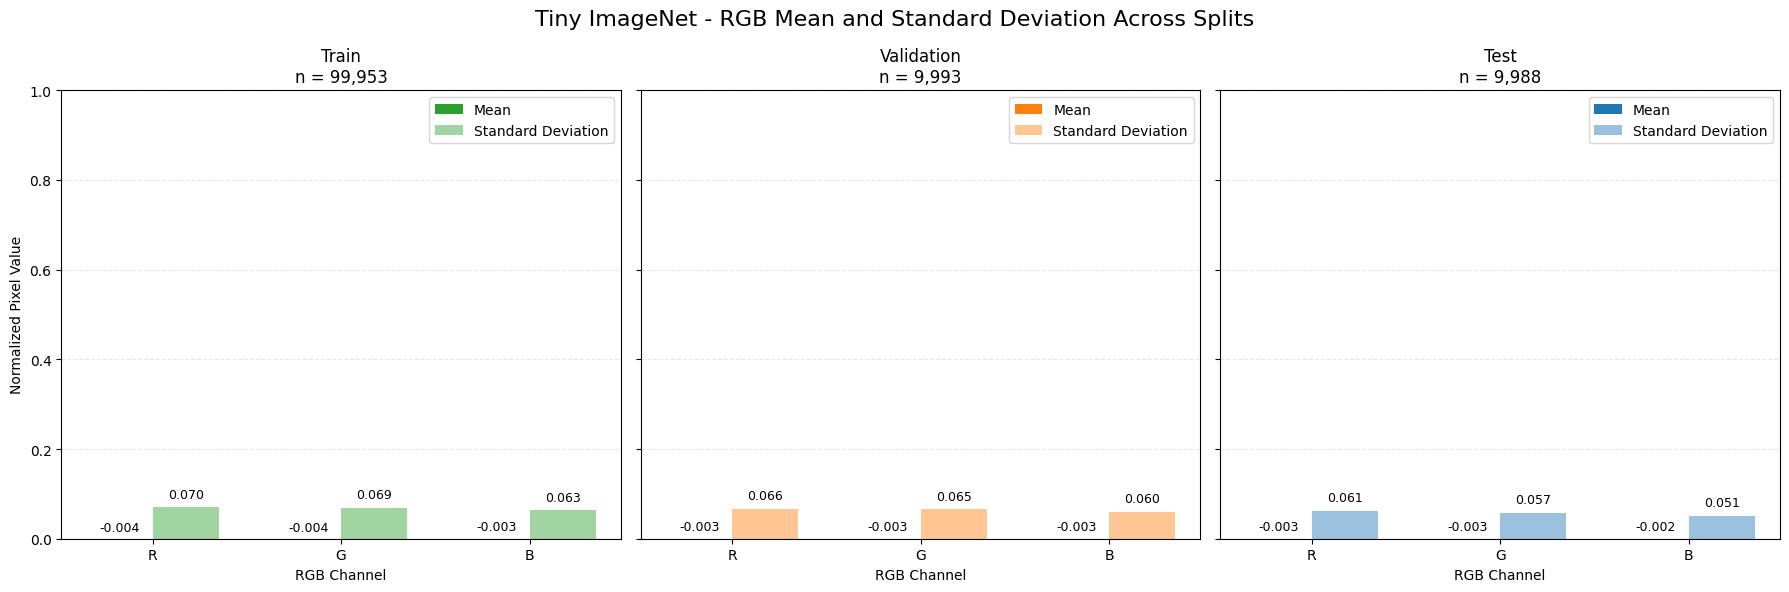

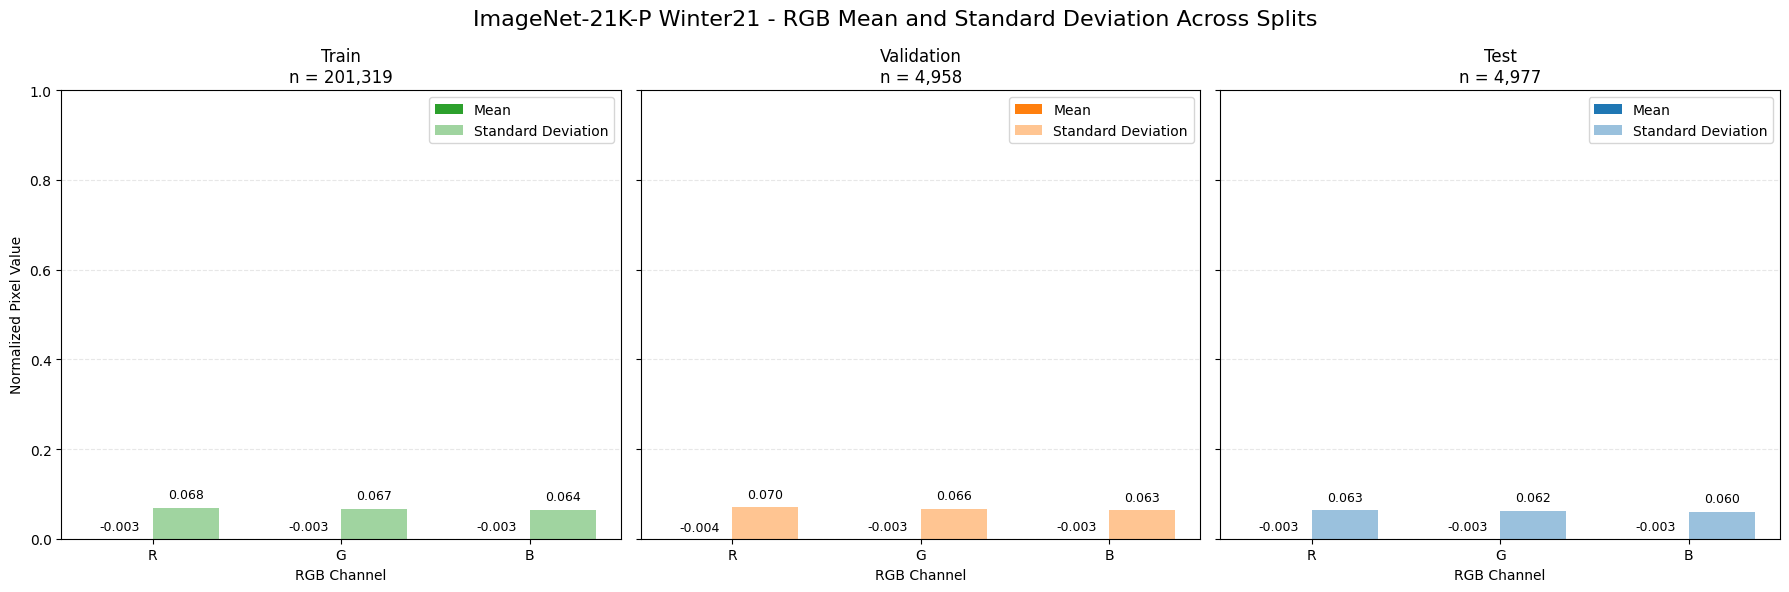

In [22]:
rgb_mean_std_analysis.plot_rgb_mean_std(
    rgb_stats
)

#### 11. Pixel Intensity Statistics

In [23]:
import src.eda.image_properties.pixel_intensity_analysis as pixel_intensity_analysis

pixel_intensity_stats, pixel_intensity_details = (
    pixel_intensity_analysis.pixel_intensity_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

pixel_intensity_stats

100%|██████████| 3/3 [10:52<00:00, 217.54s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Total Pixels,Min Intensity,Max Intensity,Mean Intensity,Median Intensity,Std Intensity,5th Percentile,25th Percentile,75th Percentile,95th Percentile
0,tiny_imagenet,Train,99953,99953,0,5015241728,-1.7247,0.9522,-0.0035,0.002,0.0673,0.002,0.002,0.0059,0.0059
1,tiny_imagenet,Validation,9993,9993,0,501408768,-1.7247,0.9063,-0.0032,0.002,0.0636,0.002,0.002,0.0059,0.0059
2,tiny_imagenet,Test,9988,9988,0,501157888,-1.7247,0.9125,-0.0027,0.002,0.0565,0.002,0.002,0.0059,0.0059
3,imagenet21k_p,Train,201319,201319,0,10101382144,-1.6694,0.9848,-0.0030,0.002,0.0654,0.002,0.002,0.0059,0.0059
4,imagenet21k_p,Validation,4958,4958,0,248772608,-1.6694,0.8801,-0.0033,0.002,0.0655,0.002,0.002,0.0059,0.0059
5,imagenet21k_p,Test,4977,4977,0,249725952,-1.6694,0.9409,-0.0027,0.002,0.0606,0.002,0.002,0.0059,0.0059


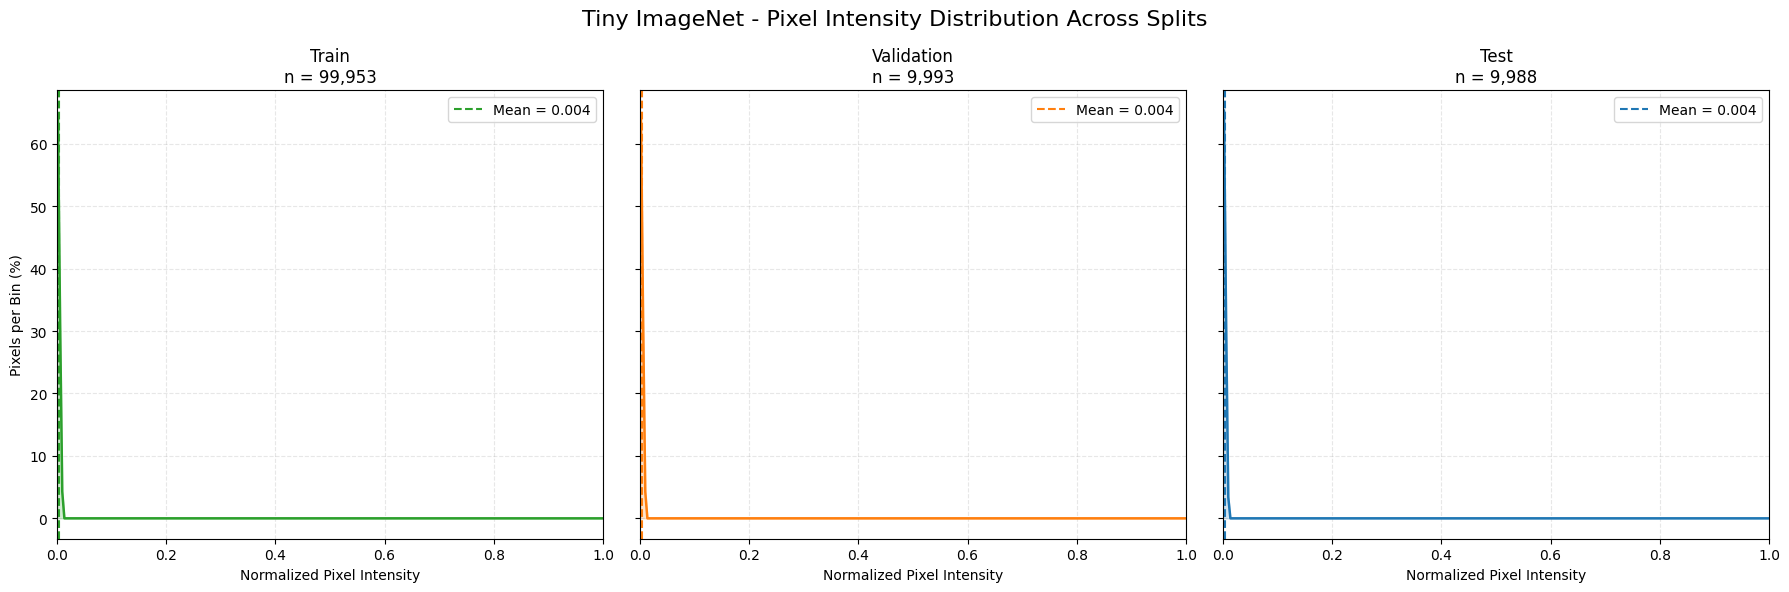

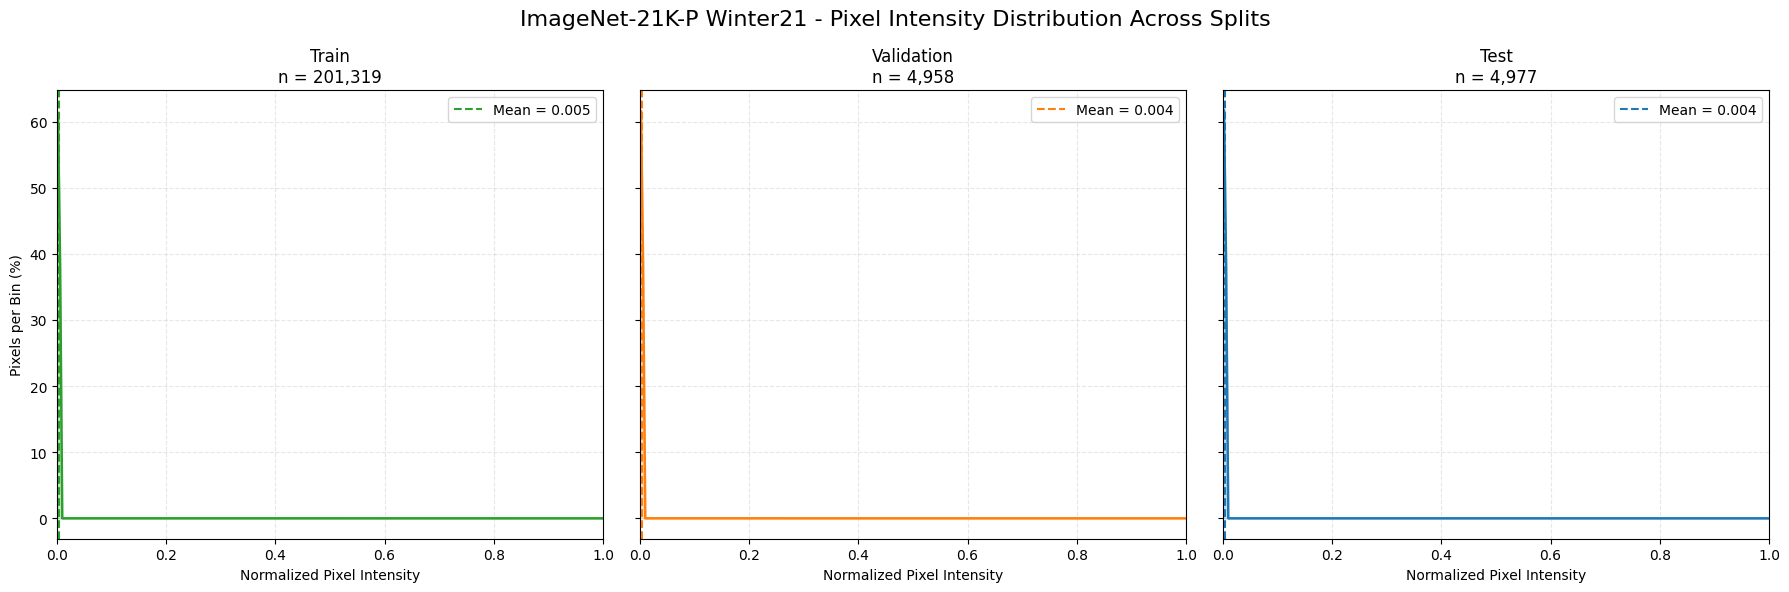

In [24]:
pixel_intensity_analysis.plot_pixel_intensity_distribution(
    pixel_intensity_details
)

## D. Image Properties

#### 12. Brightness, Contrast and Sharpness Analysis

In [25]:
import src.eda.image_quality.image_quality_analysis as image_quality_analysis

image_quality_stats, image_quality_details = (
    image_quality_analysis.image_quality_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_quality_stats

  0%|          | 0/2 [00:00<?, ?it/s]

Train:   0%|          | 0/99953 [00:00<?, ?it/s]

Validation:   0%|          | 0/9993 [00:00<?, ?it/s]

Test:   0%|          | 0/9988 [00:00<?, ?it/s]

Train:   0%|          | 0/201319 [00:00<?, ?it/s]

Validation:   0%|          | 0/4958 [00:00<?, ?it/s]

Test:   0%|          | 0/4977 [00:00<?, ?it/s]

,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Mean Brightness,Median Brightness,Std Brightness,Mean Contrast,Median Contrast,Std Contrast,Mean Sharpness,Median Sharpness,Std Sharpness
0,tiny_imagenet,Train,99953,99953,0,-0.0035,-0.0000,0.0587,0.0055,0.0031,0.0323,0.000022,0.000000,0.000392
1,tiny_imagenet,Validation,9993,9993,0,-0.0032,-0.0000,0.0572,0.0050,0.0031,0.0275,0.000017,0.000000,0.000335
2,tiny_imagenet,Test,9988,9988,0,-0.0027,-0.0001,0.0483,0.0050,0.0031,0.0289,0.000016,0.000000,0.000304
3,imagenet21k_p,Train,201319,201319,0,-0.0030,-0.0002,0.0533,0.0058,0.0030,0.0376,0.000334,0.000002,0.007358
4,imagenet21k_p,Validation,4958,4958,0,-0.0033,-0.0002,0.0563,0.0055,0.0029,0.0331,0.000428,0.000002,0.009037
5,imagenet21k_p,Test,4977,4977,0,-0.0027,-0.0003,0.0524,0.0051,0.0029,0.0300,0.000259,0.000002,0.006497


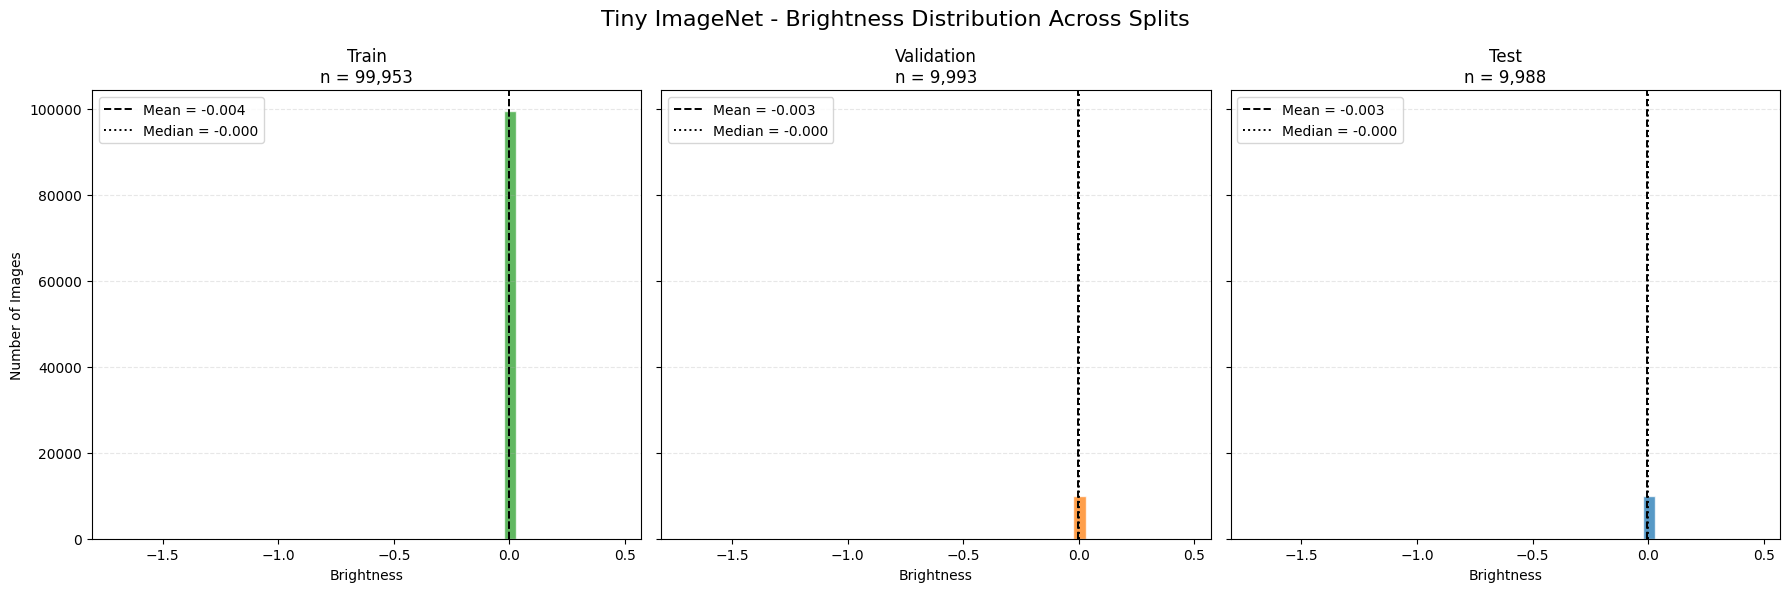

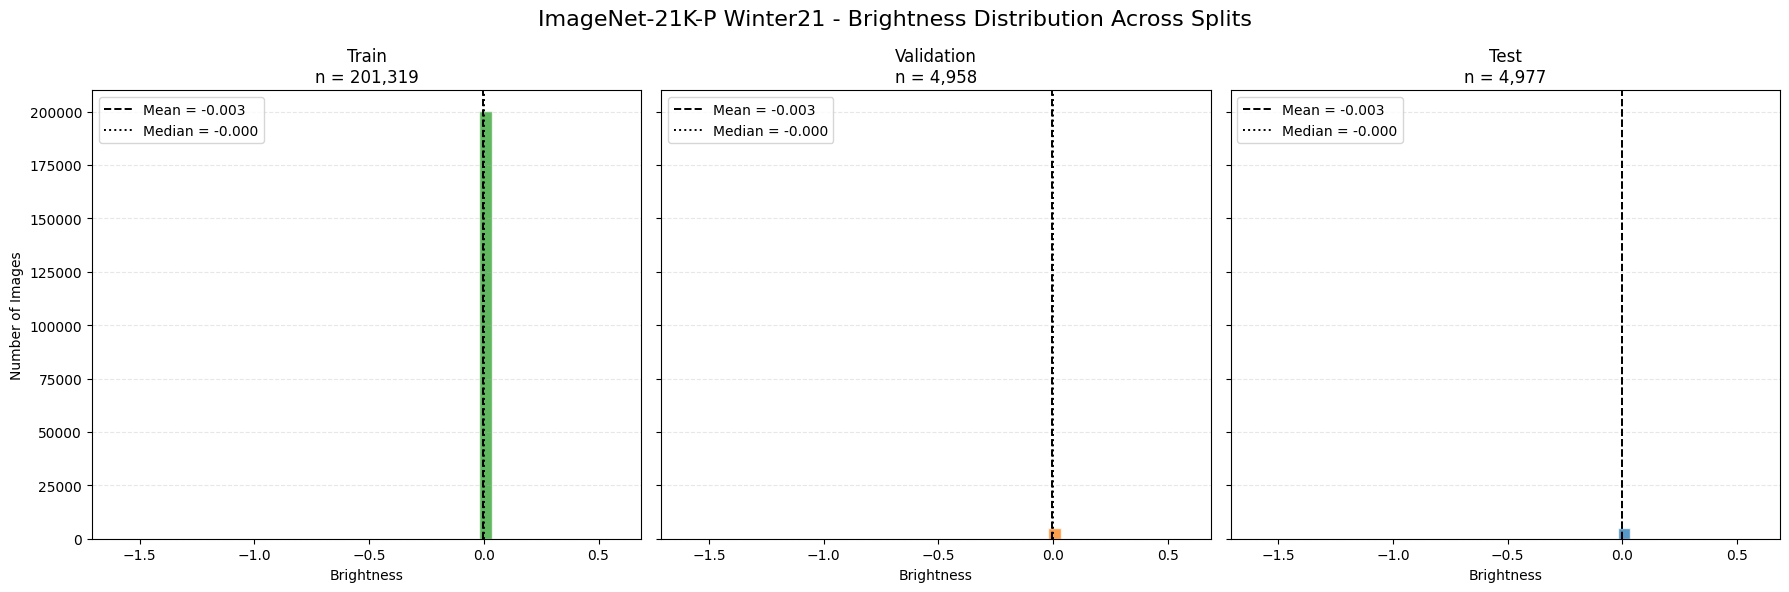

In [26]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Brightness",
)

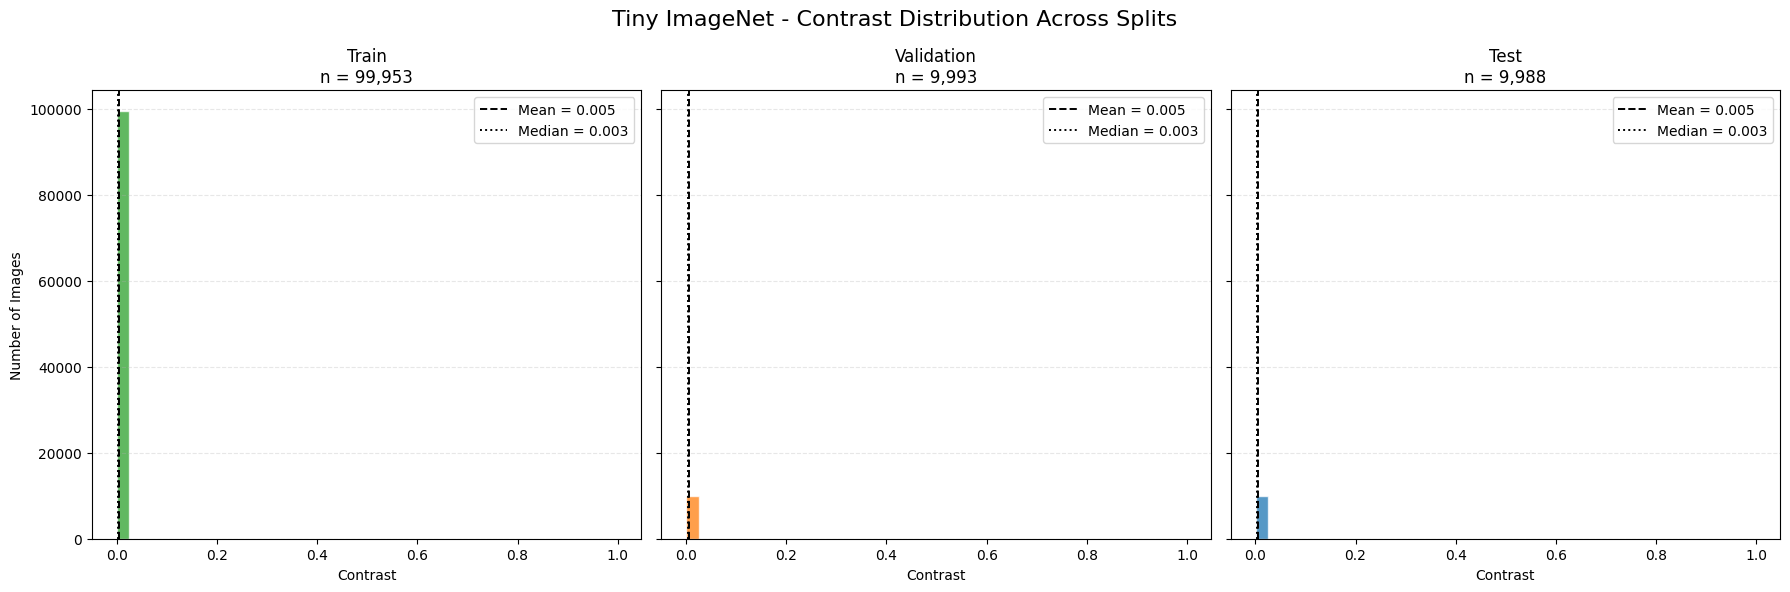

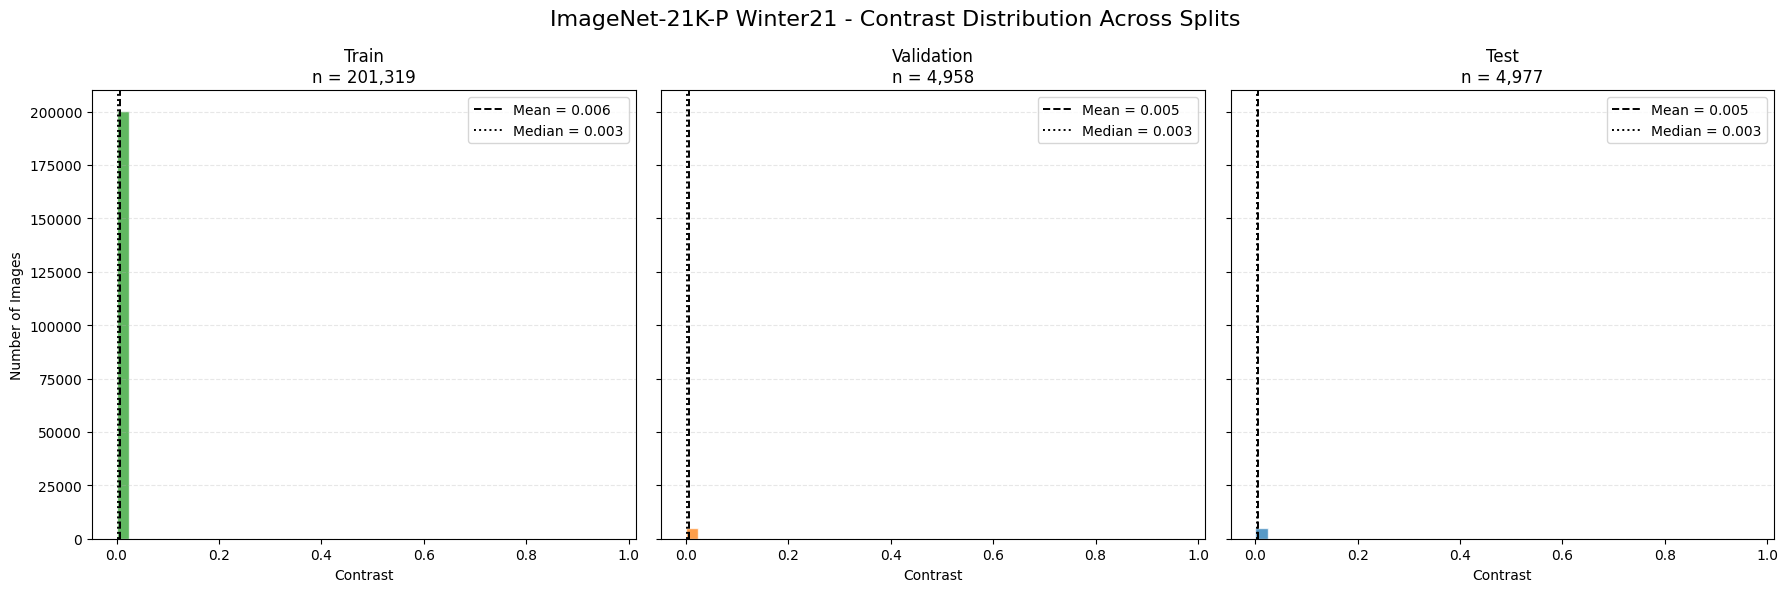

In [27]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Contrast",
)

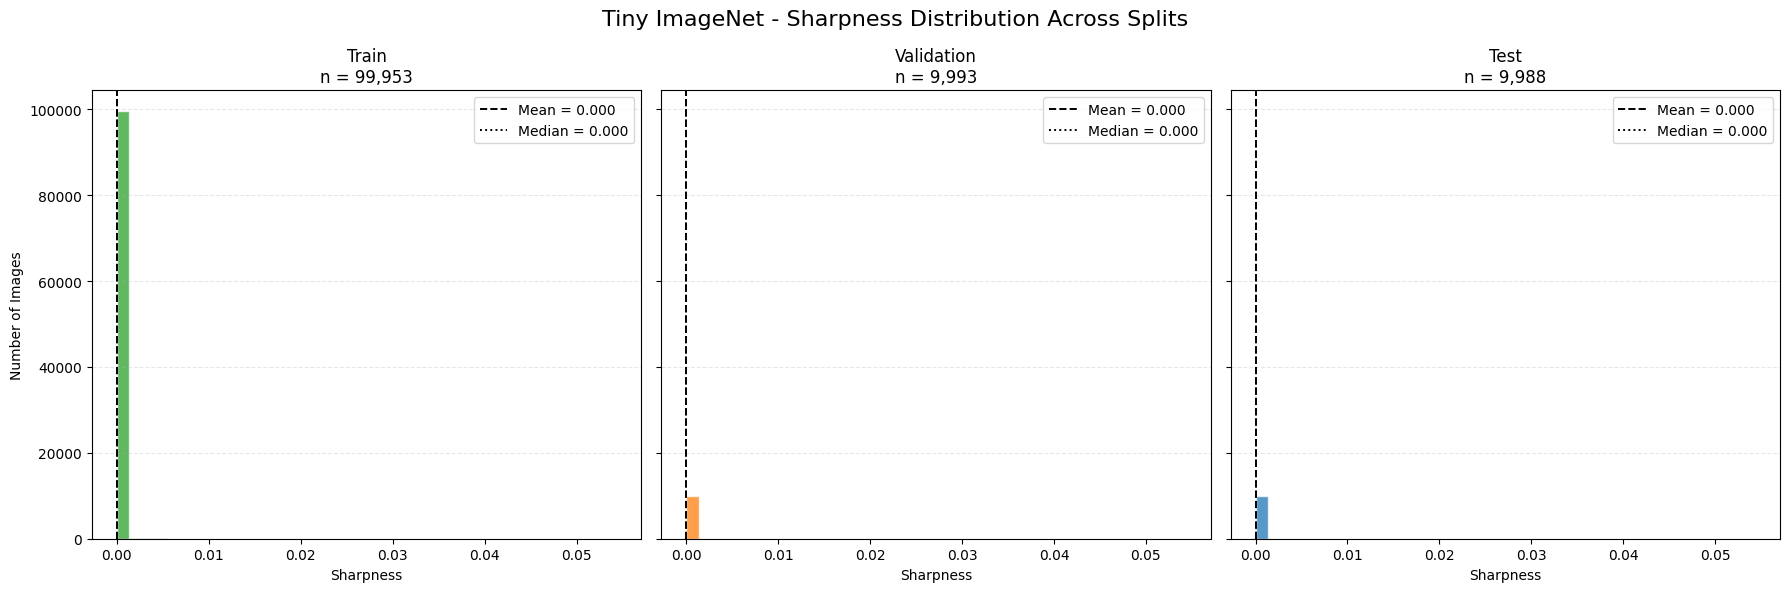

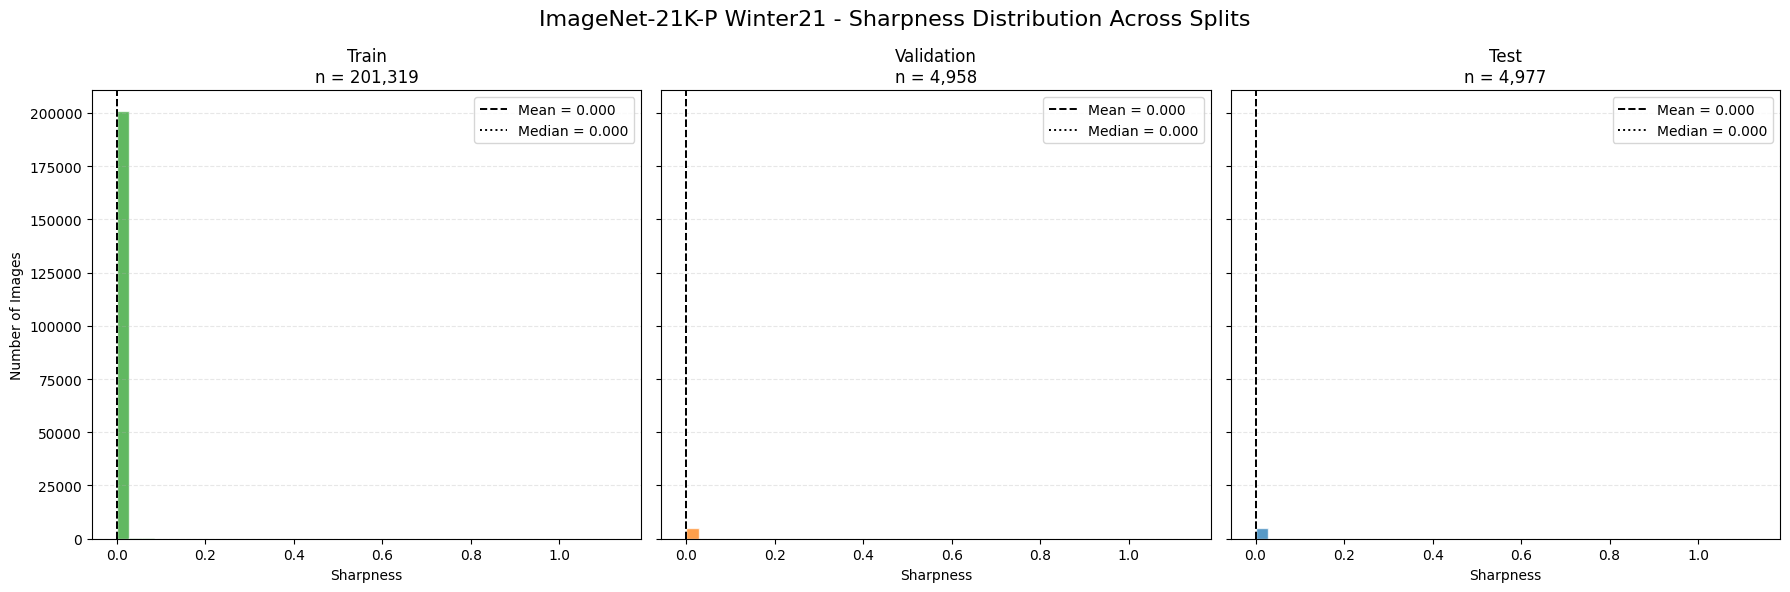

In [28]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Sharpness",
)

## E. Anomalies / Leakage

#### 13. Statistical Outlier Detection

In [29]:
import src.eda.anomalies_leakage.statistical_outlier_analysis as statistical_outlier_analysis

outlier_stats, outlier_details, outlier_thresholds = (
    statistical_outlier_analysis.statistical_outlier_analysis(
        image_dimension_details,
        image_quality_details,
        iqr_multiplier=1.5,
    )
)

outlier_stats

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]

imagenet21k_p splits:   0%|          | 0/3 [00:00<?, ?it/s]

,Dataset,Split,Analyzed Images,Outlier Images,Outlier (%),Width Outliers,Width Outlier (%),Height Outliers,Height Outlier (%),Aspect Ratio Outliers,Aspect Ratio Outlier (%),Brightness Outliers,Brightness Outlier (%),Contrast Outliers,Contrast Outlier (%),Sharpness Outliers,Sharpness Outlier (%)
0,tiny_imagenet,Train,99953,7234,7.24,0,0.0,0,0.0,0,0.0,3611,3.61,1356,1.36,3496,3.50
1,tiny_imagenet,Validation,9993,717,7.18,0,0.0,0,0.0,0,0.0,328,3.28,125,1.25,370,3.70
2,tiny_imagenet,Test,9988,664,6.65,0,0.0,0,0.0,0,0.0,322,3.22,119,1.19,327,3.27
3,imagenet21k_p,Train,201319,21824,10.84,0,0.0,0,0.0,0,0.0,9565,4.75,3059,1.52,11982,5.95
4,imagenet21k_p,Validation,4958,532,10.73,0,0.0,0,0.0,0,0.0,237,4.78,77,1.55,283,5.71
5,imagenet21k_p,Test,4977,576,11.57,0,0.0,0,0.0,0,0.0,292,5.87,75,1.51,273,5.49


In [30]:
outlier_details["tiny_imagenet"]["Train"][
    outlier_details["tiny_imagenet"]["Train"]["Is Outlier"]
].head(5)

,Image Index,Width,Height,Aspect Ratio,Brightness,Contrast,Sharpness,Width Outlier,Height Outlier,Aspect Ratio Outlier,Brightness Outlier,Contrast Outlier,Sharpness Outlier,Outlier Count,Is Outlier,Outlier Metrics
75,75,224,224,1.0,-0.004135,0.000760,1.327456e-08,False,False,False,False,True,False,1,True,Contrast
87,87,224,224,1.0,0.006730,0.002248,3.663181e-08,False,False,False,True,False,False,1,True,Brightness
107,107,224,224,1.0,0.006990,0.002081,2.726005e-08,False,False,False,True,False,False,1,True,Brightness
108,108,224,224,1.0,-0.587515,0.295459,2.760614e-04,False,False,False,True,True,True,3,True,"Brightness, Contrast, Sharpness"
117,117,224,224,1.0,-1.418407,0.285558,3.831212e-04,False,False,False,True,True,True,3,True,"Brightness, Contrast, Sharpness"


In [31]:
outlier_details["imagenet21k_p"]["Train"][
    outlier_details["imagenet21k_p"]["Train"]["Is Outlier"]
].head(5)

,Image Index,Width,Height,Aspect Ratio,Brightness,Contrast,Sharpness,Width Outlier,Height Outlier,Aspect Ratio Outlier,Brightness Outlier,Contrast Outlier,Sharpness Outlier,Outlier Count,Is Outlier,Outlier Metrics
6,6,224,224,1.0,-0.647184,0.532340,0.038375,False,False,False,True,True,True,3,True,"Brightness, Contrast, Sharpness"
39,39,224,224,1.0,-0.001060,0.003003,0.000011,False,False,False,False,False,True,1,True,Sharpness
44,44,224,224,1.0,-0.001502,0.003080,0.000008,False,False,False,False,False,True,1,True,Sharpness
62,62,224,224,1.0,0.000198,0.004382,0.000008,False,False,False,False,False,True,1,True,Sharpness
87,87,224,224,1.0,0.000651,0.002852,0.000009,False,False,False,False,False,True,1,True,Sharpness


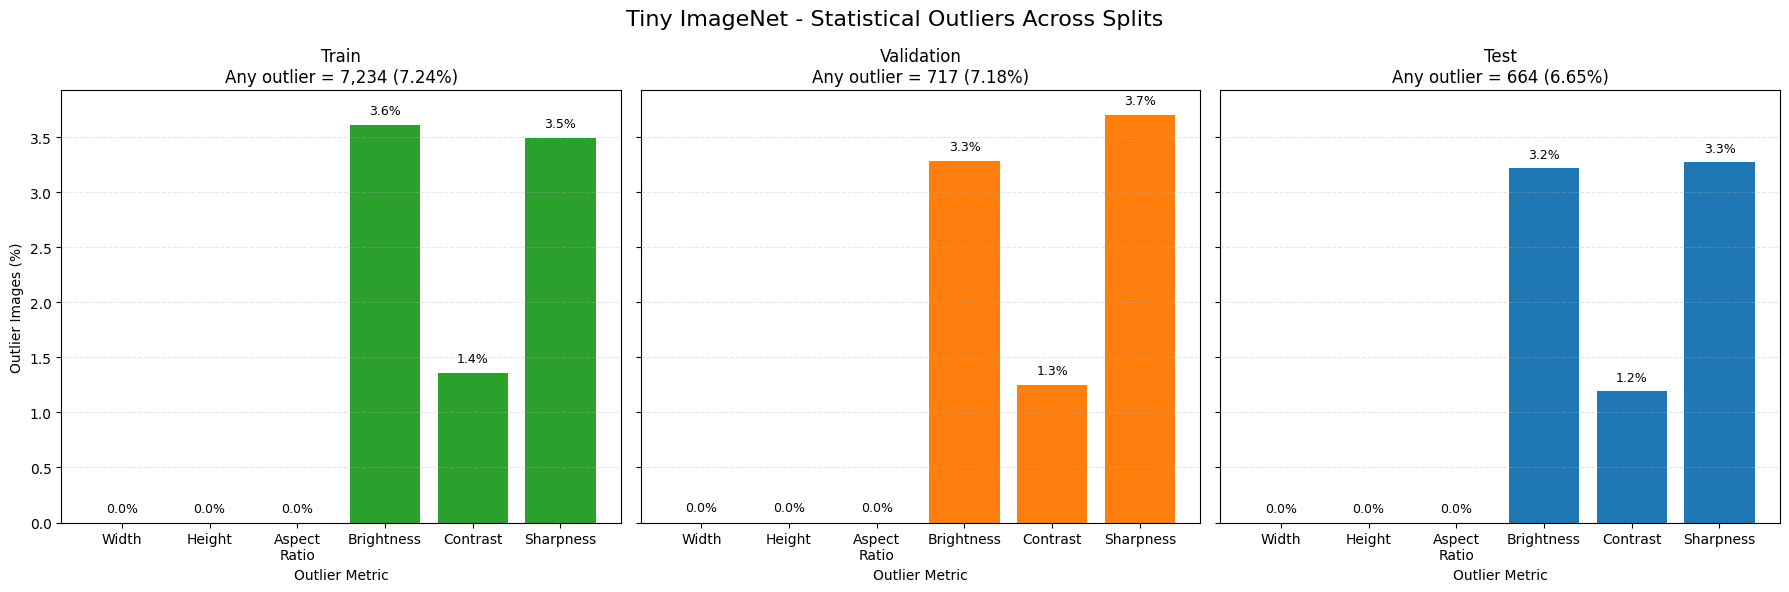

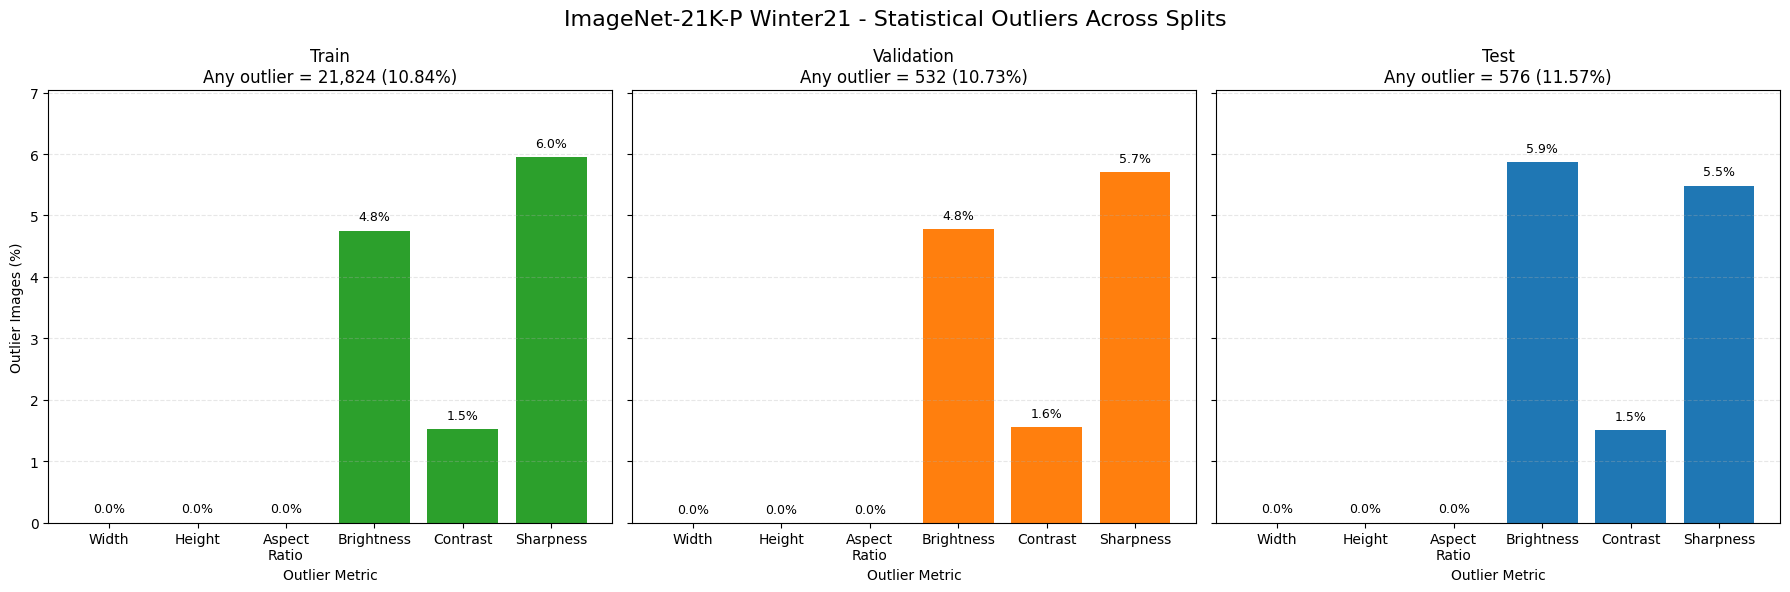

In [32]:
statistical_outlier_analysis.plot_statistical_outliers(
    outlier_details
)

#### 14. Corrupted Image Detection

In [33]:
import src.eda.anomalies_leakage.corrupted_image_analysis as corrupted_image_analysis

corruption_stats, corrupted_details = (
    corrupted_image_analysis.corrupted_image_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

corruption_stats

  0%|          | 0/2 [00:00<?, ?it/s]

Train:   0%|          | 0/99953 [00:00<?, ?it/s]

Validation:   0%|          | 0/9993 [00:00<?, ?it/s]

Test:   0%|          | 0/9988 [00:00<?, ?it/s]

Train:   0%|          | 0/201319 [00:00<?, ?it/s]

Validation:   0%|          | 0/4958 [00:00<?, ?it/s]

Test:   0%|          | 0/4977 [00:00<?, ?it/s]

,Dataset,Split,Total Images,Analyzed Images,Valid Images,Corrupted Images,Corrupted (%),Integrity Status
0,tiny_imagenet,Train,99953,99953,99953,0,0.0,Passed
1,tiny_imagenet,Validation,9993,9993,9993,0,0.0,Passed
2,tiny_imagenet,Test,9988,9988,9988,0,0.0,Passed
3,imagenet21k_p,Train,201319,201319,201319,0,0.0,Passed
4,imagenet21k_p,Validation,4958,4958,4958,0,0.0,Passed
5,imagenet21k_p,Test,4977,4977,4977,0,0.0,Passed


In [34]:
corrupted_details["imagenet21k_p"]["Train"]

""


In [35]:
corrupted_details["imagenet21k_p"]["Train"][
    "Error Type"
].value_counts()

KeyError: 'Error Type'

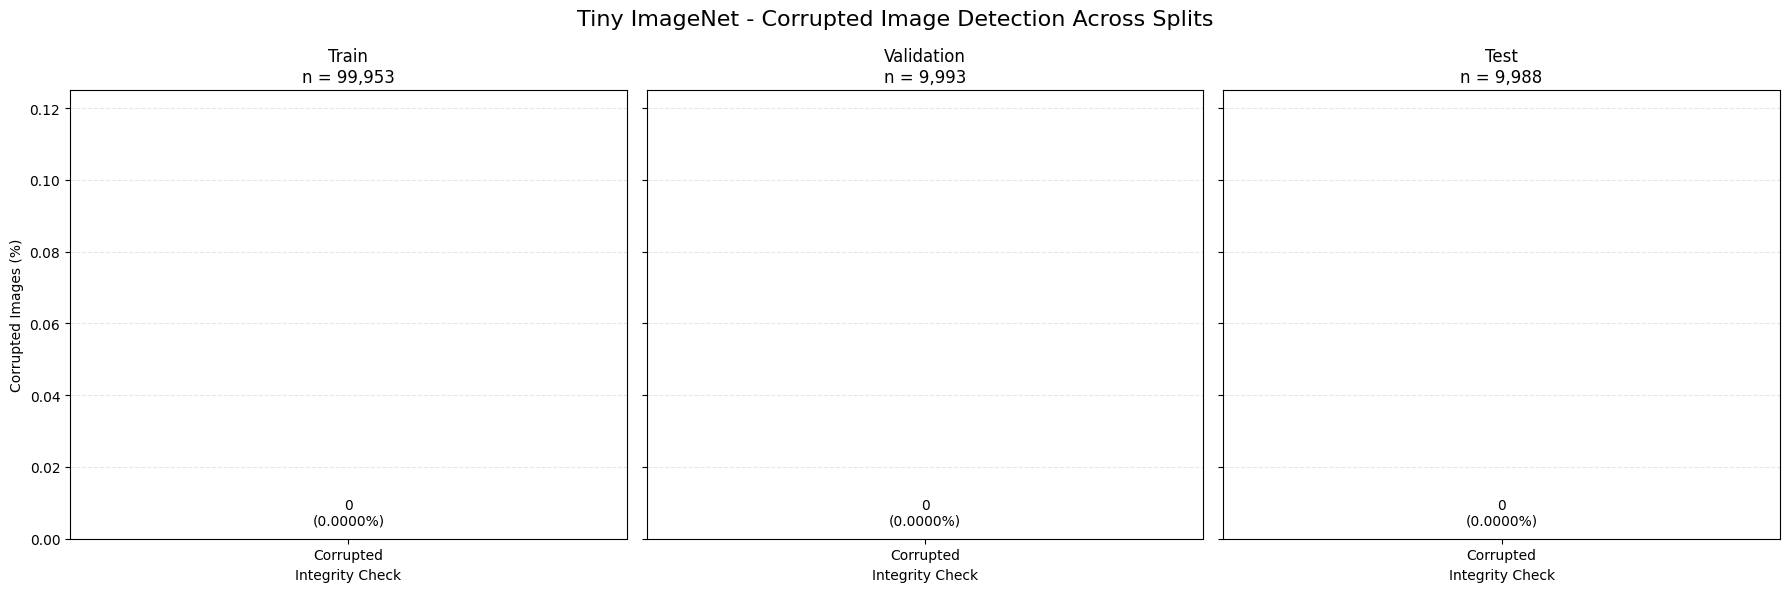

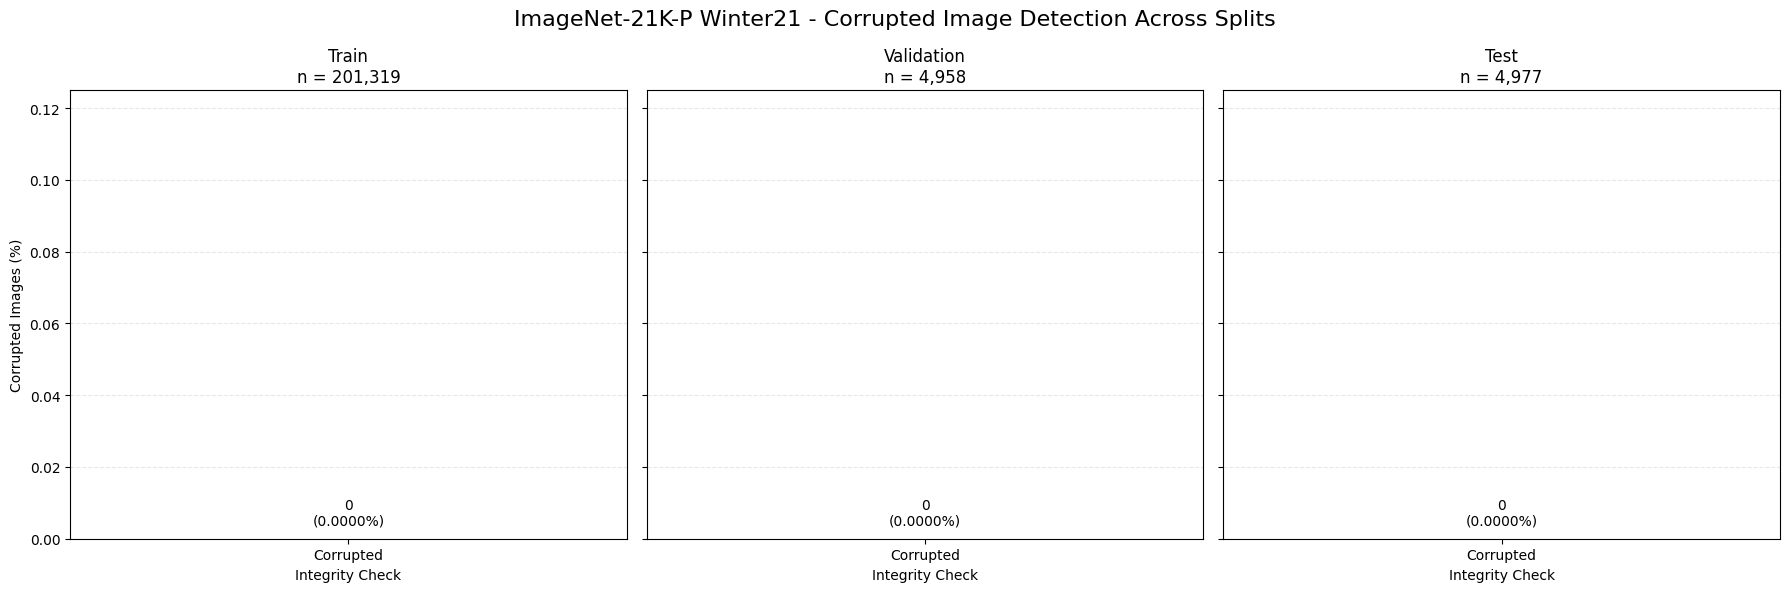

In [36]:
corrupted_image_analysis.plot_corrupted_images(
    corruption_stats
)

#### 15. Duplicate Image and Data Leakage Detection

In [37]:
import src.eda.anomalies_leakage.duplicate_leakage_analysis as duplicate_leakage_analysis

duplicate_stats, duplicate_details = (
    duplicate_leakage_analysis.duplicate_leakage_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

duplicate_stats

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/99953 [00:00<?, ?it/s]

Validation:   0%|          | 0/9993 [00:00<?, ?it/s]

Test:   0%|          | 0/9988 [00:00<?, ?it/s]

imagenet21k_p splits:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/201319 [00:00<?, ?it/s]

Validation:   0%|          | 0/4958 [00:00<?, ?it/s]

Test:   0%|          | 0/4977 [00:00<?, ?it/s]

,Dataset,Analyzed Images,Hash Failures,Train Duplicate Groups,Train Duplicate Images,Train Duplicate (%),Validation Duplicate Groups,Validation Duplicate Images,Validation Duplicate (%),Test Duplicate Groups,Test Duplicate Images,Test Duplicate (%),Train ↔ Validation Leakage,Train ↔ Test Leakage,Validation ↔ Test Leakage,Unique Leakage Groups,Leakage Status
0,tiny_imagenet,119934,0,1,9,0.0090,1,1,0.01,0,0,0.0,1,1,1,1,Leakage Detected
1,imagenet21k_p,211254,0,1,9,0.0045,0,0,0.00,0,0,0.0,0,1,0,1,Leakage Detected


##### Inspect within-split duplicates

In [38]:
duplicate_details["tiny_imagenet"]["Train Duplicates"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,2030,4.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
1,Train,4386,8.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
2,Train,6637,13.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
3,Train,20768,41.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
4,Train,27862,55.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...


In [39]:
duplicate_details["imagenet21k_p"]["Train Duplicates"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,15527,13,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
1,Train,21490,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
2,Train,21515,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
3,Train,21615,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
4,Train,21988,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...


##### Inspect specific leakage records

In [40]:
duplicate_details["tiny_imagenet"]["Cross-Split Leakage"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Test,7172,NaN,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
1,Train,2030,4.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
2,Train,4386,8.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
3,Train,6637,13.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
4,Train,20768,41.0,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...


In [41]:
duplicate_details["imagenet21k_p"]["Cross-Split Leakage"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Test,4557,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
1,Train,15527,13,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
2,Train,21490,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
3,Train,21515,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...
4,Train,21615,18,None,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...


##### Duplicate plots

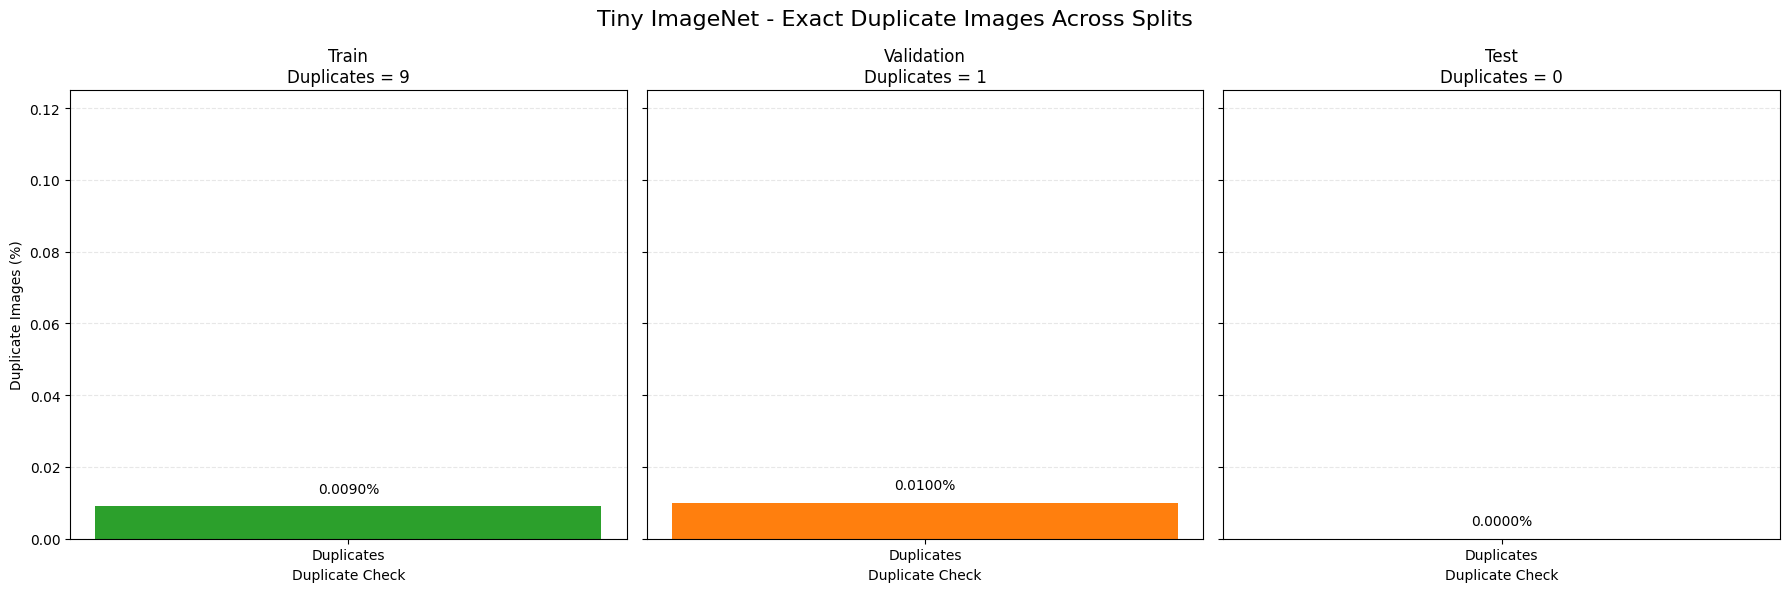

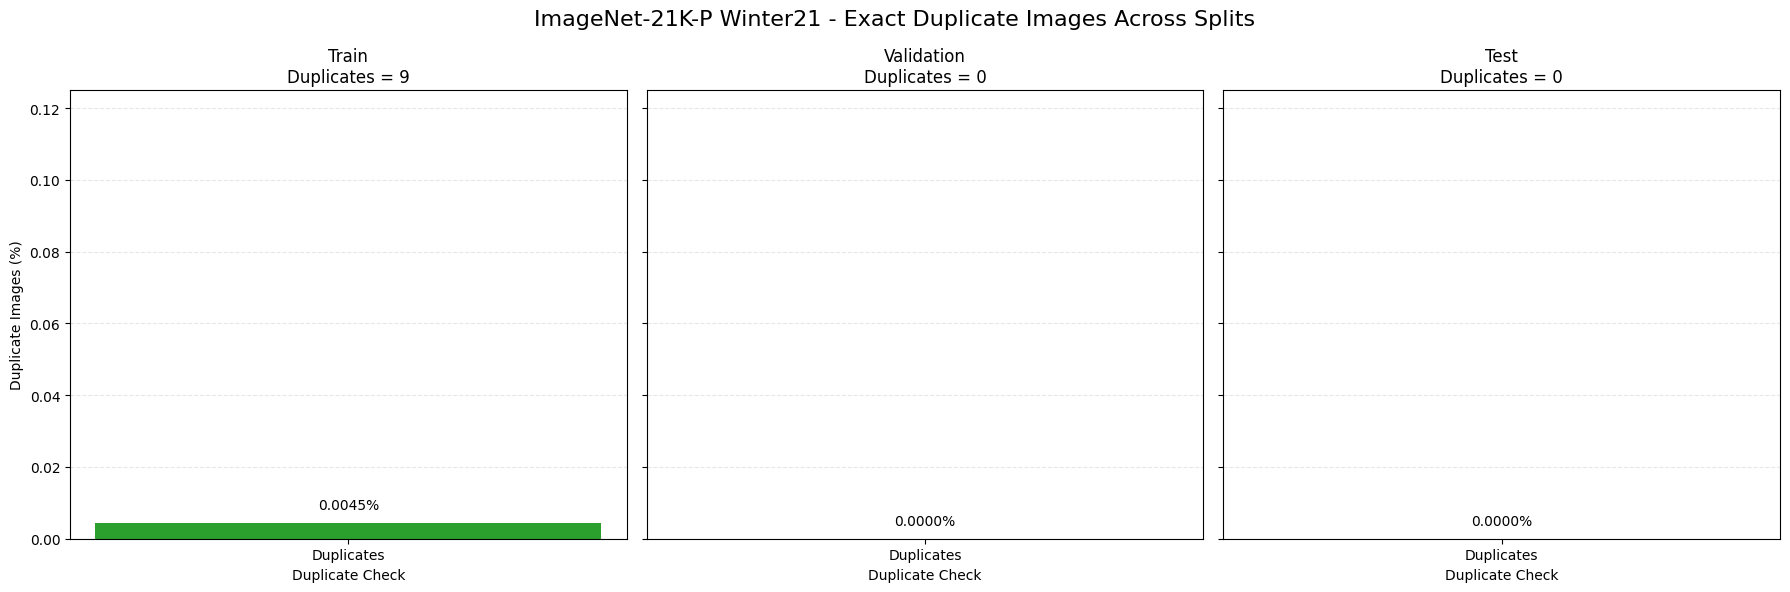

In [42]:
duplicate_leakage_analysis.plot_duplicate_images(
    duplicate_stats
)

##### Leakage plots

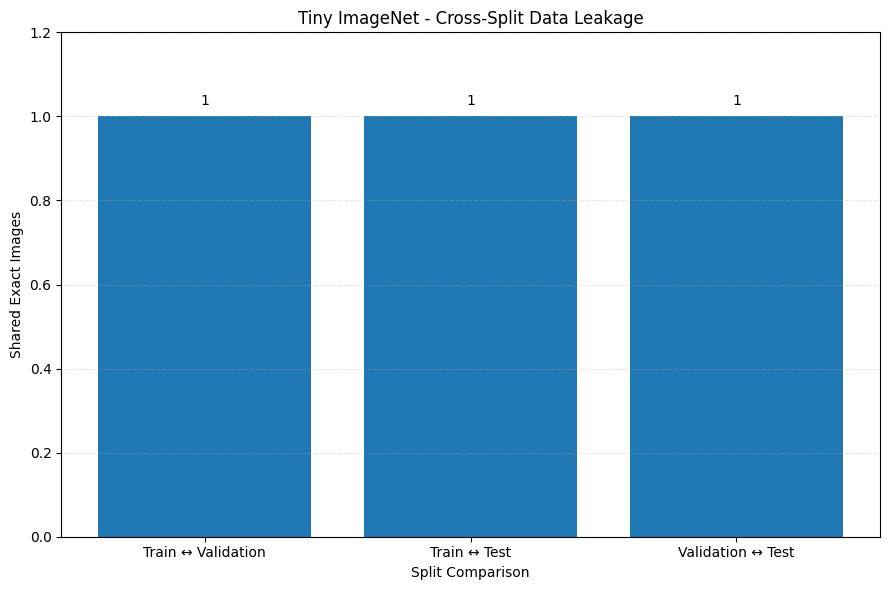

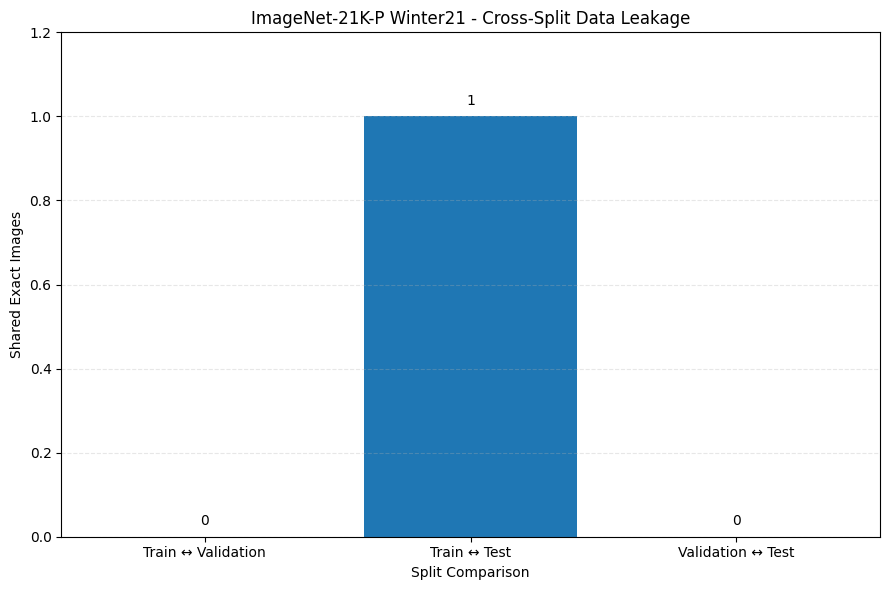

In [43]:
duplicate_leakage_analysis.plot_data_leakage(
    duplicate_stats
)

##### Label consistency check

In [44]:
duplicate_label_details = (
    duplicate_leakage_analysis.analyze_duplicate_label_consistency(
        duplicate_details
    )
)

duplicate_label_details

,Dataset,Hash,Occurrences,Splits,Unique Targets,Targets,Label Consistency
0,tiny_imagenet,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...,13,"Test, Train, Validation",11,"4, 8, 13, 41, 55, 59, 72, 92, 113, 123, 197",Conflict
1,imagenet21k_p,c7fe36dc9ab7261676591ba622533bebfdb5e771656db4...,11,"Test, Train",5,"13, 18, 27, 73, 116",Conflict


In [45]:
duplicate_label_summary = (
    duplicate_leakage_analysis.duplicate_label_consistency_summary(
        duplicate_label_details
    )
)

duplicate_label_summary

,Dataset,Label Consistency,Leakage Groups
0,imagenet21k_p,Conflict,1
1,tiny_imagenet,Conflict,1


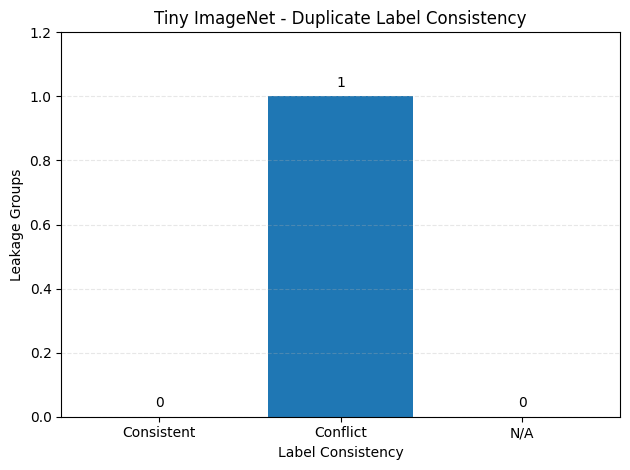

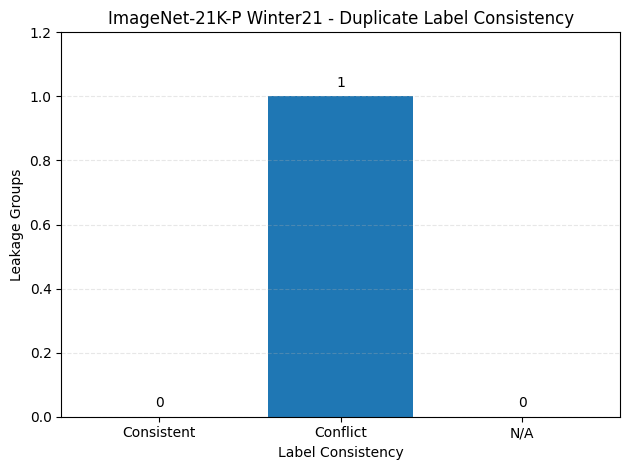

In [46]:
duplicate_leakage_analysis.plot_label_consistency(
    duplicate_label_details
)

## F. Class Variation

#### 16. Intra-Class Variation Analysis

In [47]:
import src.eda.class_variation.intra_class_variation_analysis as intra_class_variation_analysis

In [48]:

intra_class_stats, intra_class_details = (
    intra_class_variation_analysis.intra_class_variation_analysis(
        dataset_list=dataset_list,
        max_classes=200,
        max_images_per_class=50,
        min_images_per_class=2,
        feature_size=32,
        seed=42,
    )
)

intra_class_stats

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/200 [00:00<?, ?it/s]

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

imagenet21k_p splits:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/200 [00:00<?, ?it/s]

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

Test:   0%|          | 0/200 [00:00<?, ?it/s]

,Dataset,Split,Label Status,Classes Available,Classes Analyzed,Images Analyzed,Mean Intra-Class Variation,Median Intra-Class Variation,Std Intra-Class Variation,Min Intra-Class Variation,Max Intra-Class Variation,Status
0,tiny_imagenet,Train,Labelled,200,200,10000,0.003314,0.002372,0.002538,0.001661,0.016621,Analyzed
1,tiny_imagenet,Validation,Labelled,200,200,9993,0.002952,0.002346,0.002926,0.00163,0.034348,Analyzed
2,tiny_imagenet,Test,Unlabelled,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,200,200,10000,0.004108,0.002226,0.004663,0.00118,0.027111,Analyzed
4,imagenet21k_p,Validation,Labelled,200,200,4958,0.00363,0.002151,0.005429,0.001231,0.038067,Analyzed
5,imagenet21k_p,Test,Labelled,200,200,4977,0.003547,0.002114,0.005028,0.001218,0.030952,Analyzed


In [49]:
intra_class_details.sort_values(
    "Intra-Class Variation",
    ascending=False,
).head(5)

,Dataset,Split,Class ID,Class Name,Available Images,Analyzed Images,Intra-Class Variation,Min Distance,Max Distance,Mean Distance,Median Distance
675,imagenet21k_p,Validation,75,dogsled,25,25,0.038067,0.018385,0.474311,0.038067,0.020110
624,imagenet21k_p,Validation,24,grebe,24,24,0.036817,0.017523,0.441249,0.036817,0.019666
210,tiny_imagenet,Validation,10,centipede,50,50,0.034348,0.012897,0.327133,0.034348,0.016973
609,imagenet21k_p,Validation,9,hawk,24,24,0.032220,0.014498,0.385343,0.032220,0.017355
989,imagenet21k_p,Test,189,balsam poplar,25,25,0.030952,0.013739,0.385384,0.030952,0.016359


In [50]:
intra_class_details.sort_values(
    "Intra-Class Variation",
    ascending=True,
).head(5)

,Dataset,Split,Class ID,Class Name,Available Images,Analyzed Images,Intra-Class Variation,Min Distance,Max Distance,Mean Distance,Median Distance
582,imagenet21k_p,Train,182,herb Paris,1021,50,0.001180,0.000711,0.003054,0.001180,0.001164
974,imagenet21k_p,Test,174,calypso,24,24,0.001218,0.000612,0.003156,0.001218,0.001126
560,imagenet21k_p,Train,160,buttercup,1178,50,0.001220,0.000719,0.002565,0.001220,0.001073
794,imagenet21k_p,Validation,194,royal fern,25,25,0.001231,0.000713,0.002167,0.001231,0.001114
567,imagenet21k_p,Train,167,winter purslane,458,50,0.001245,0.000651,0.002275,0.001245,0.001195


##### Visualization 1: Variation distribution across splits

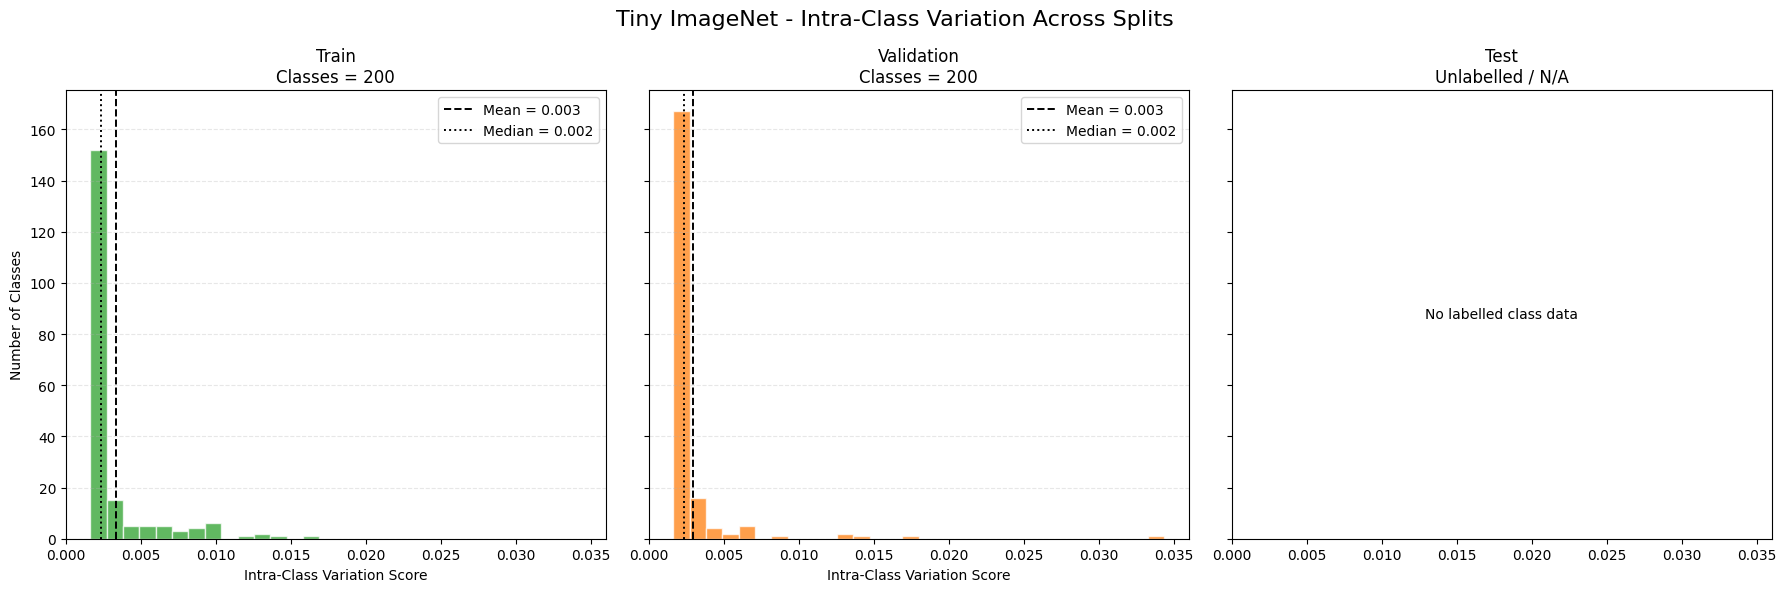

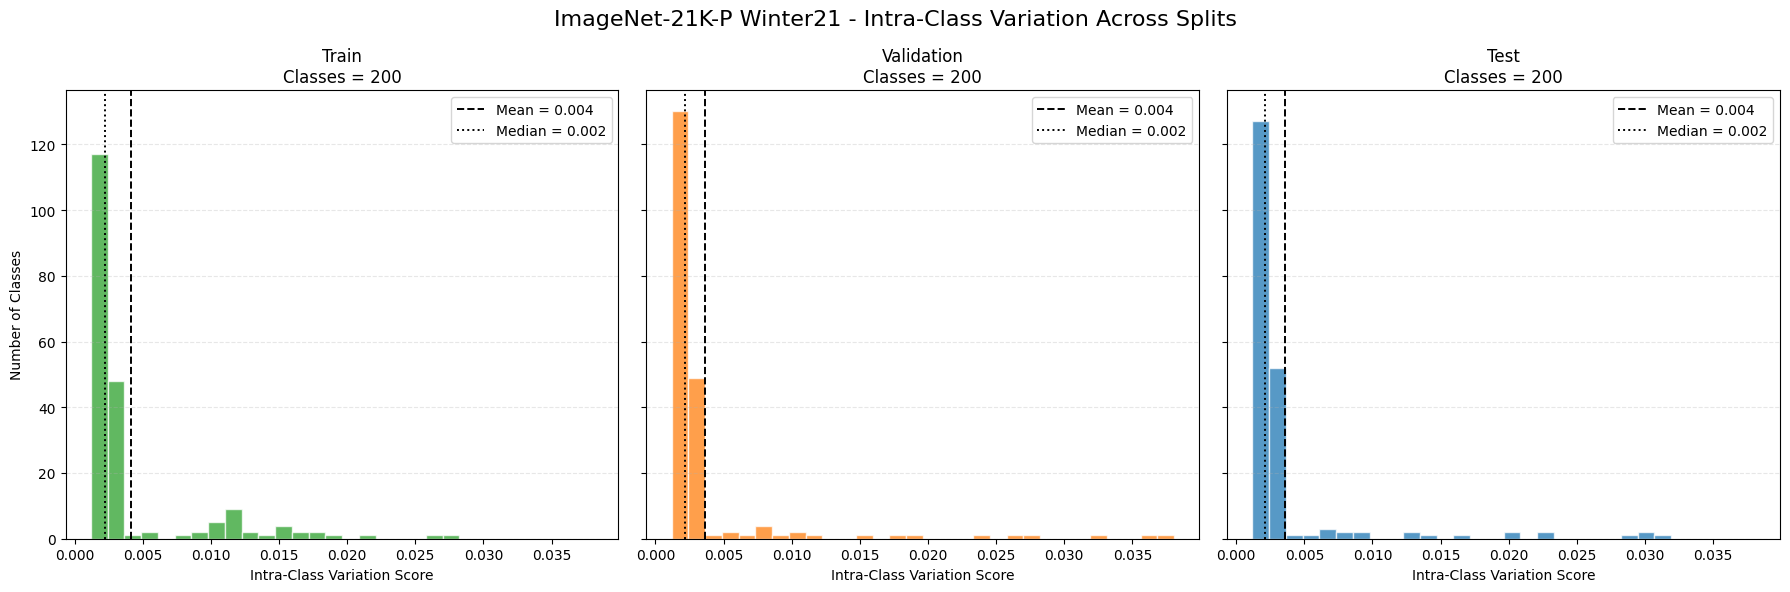

In [51]:
intra_class_variation_analysis.plot_intra_class_distribution(
    intra_class_details
)

##### Visualization 2: Top 10 most variable classes

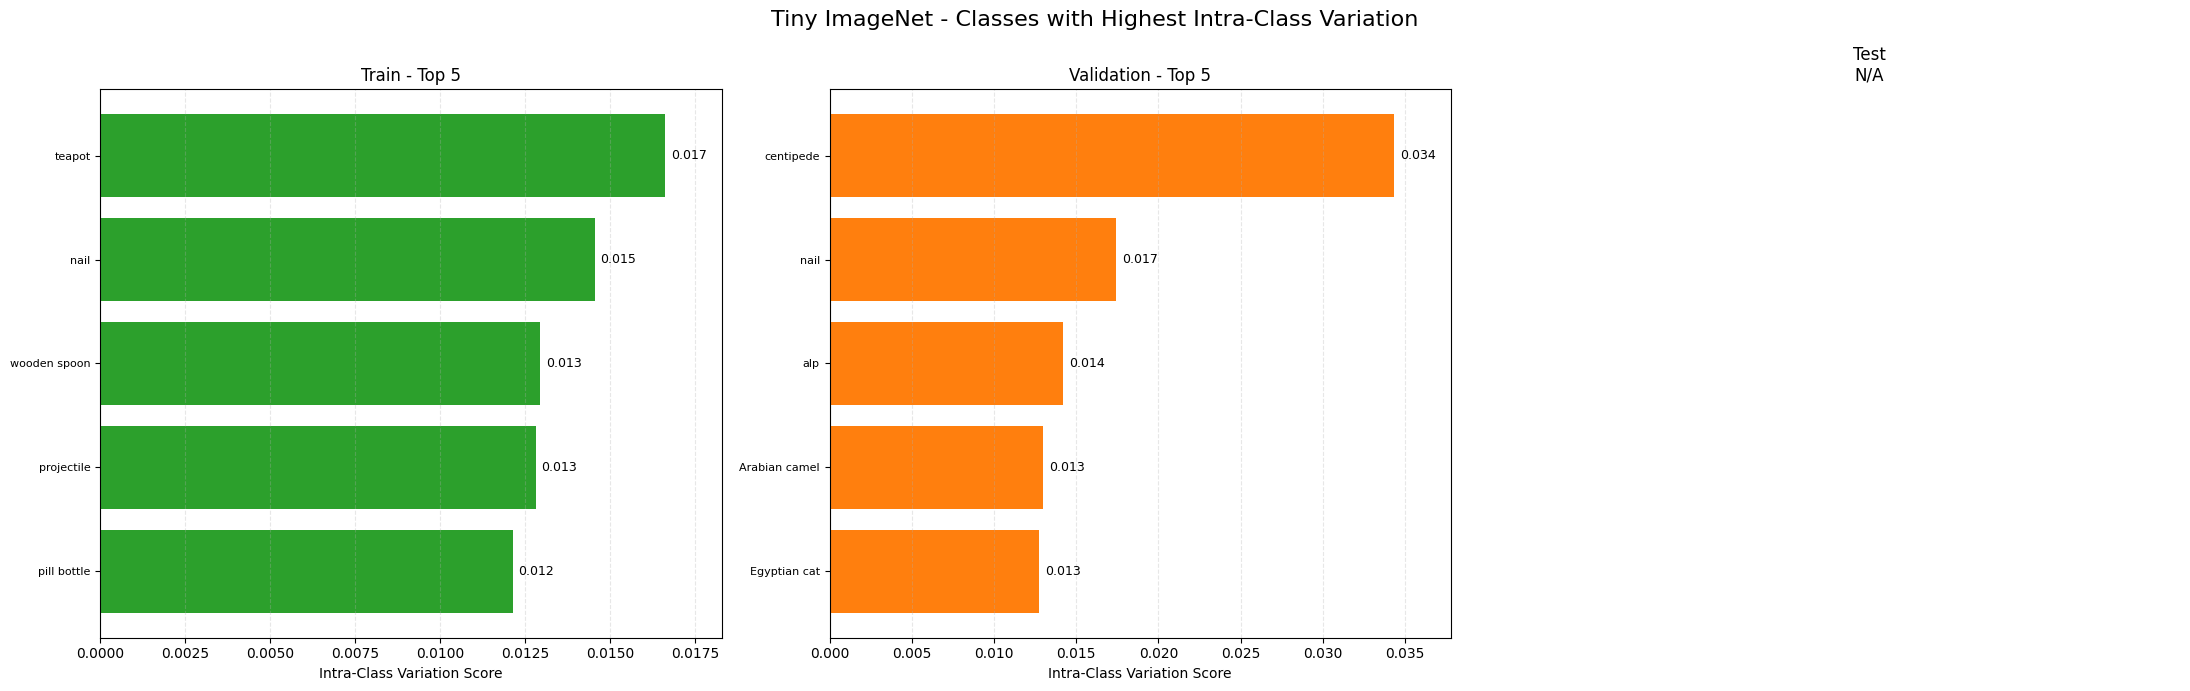

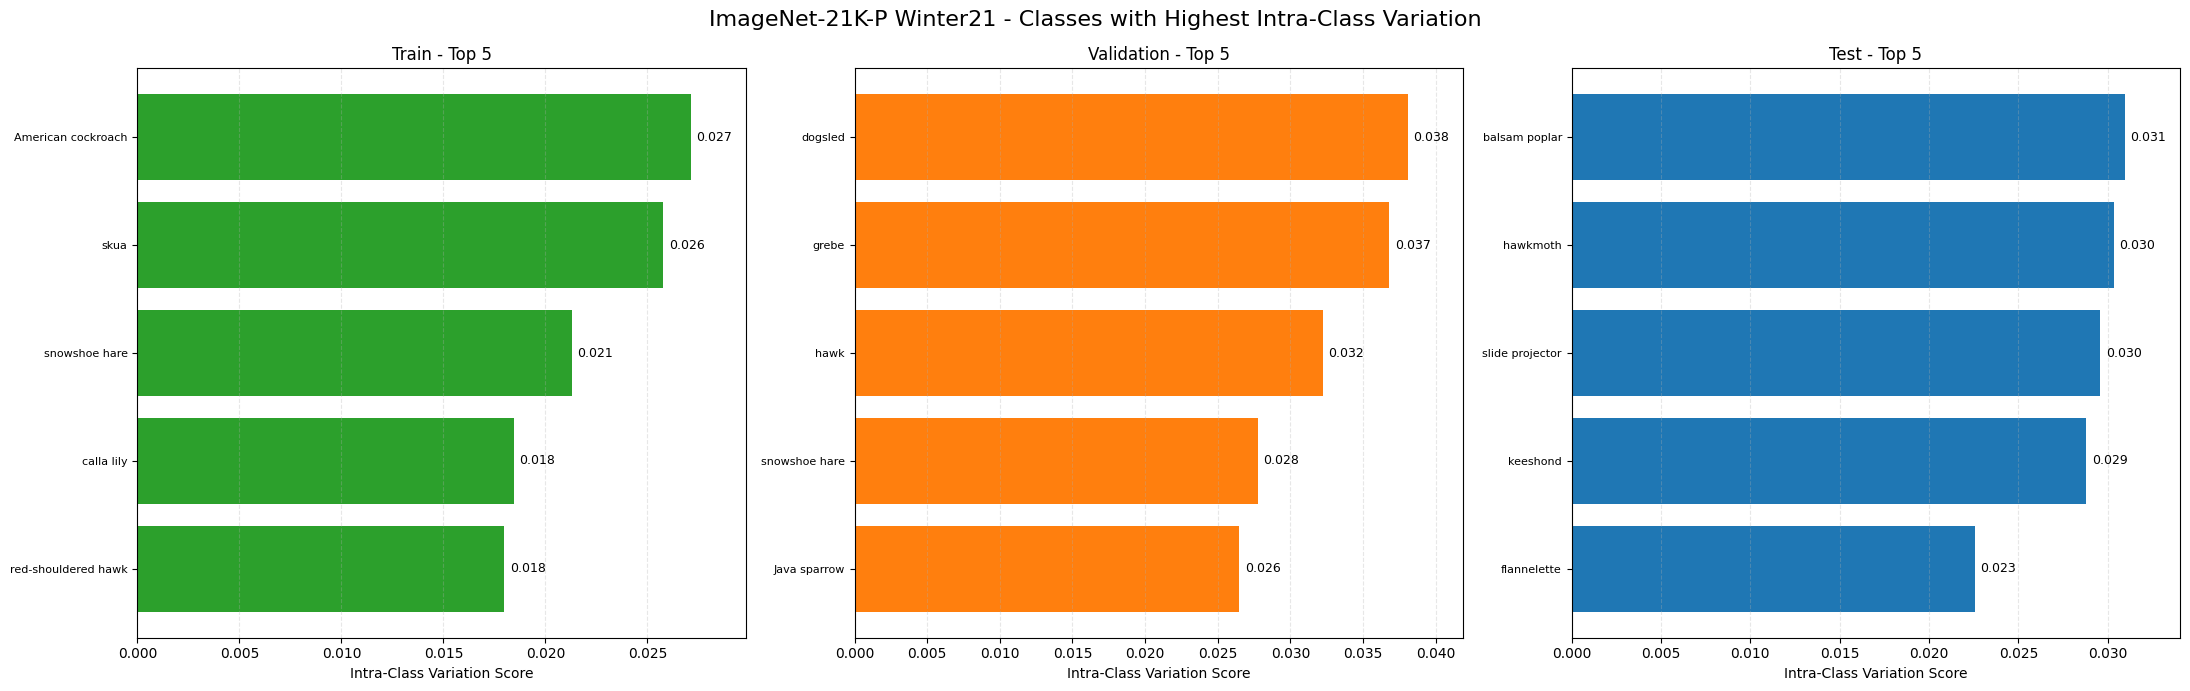

In [52]:
intra_class_variation_analysis.plot_top_variable_classes(
    intra_class_details,
    top_n=5,
)

##### Visualization 3: Lowest 10 variable classes

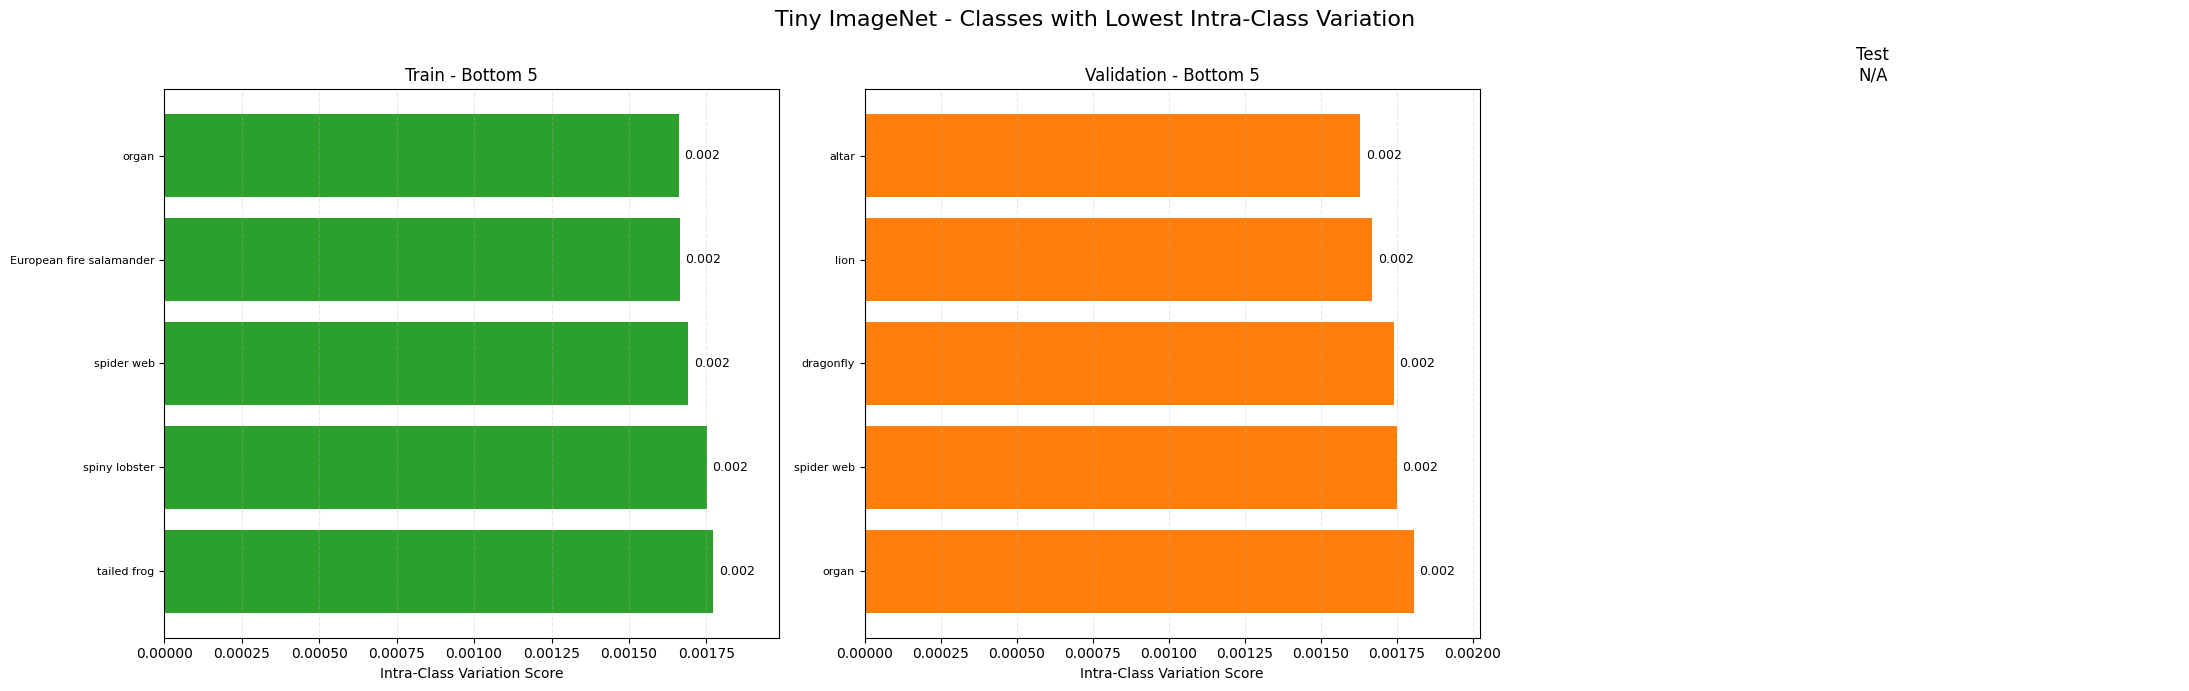

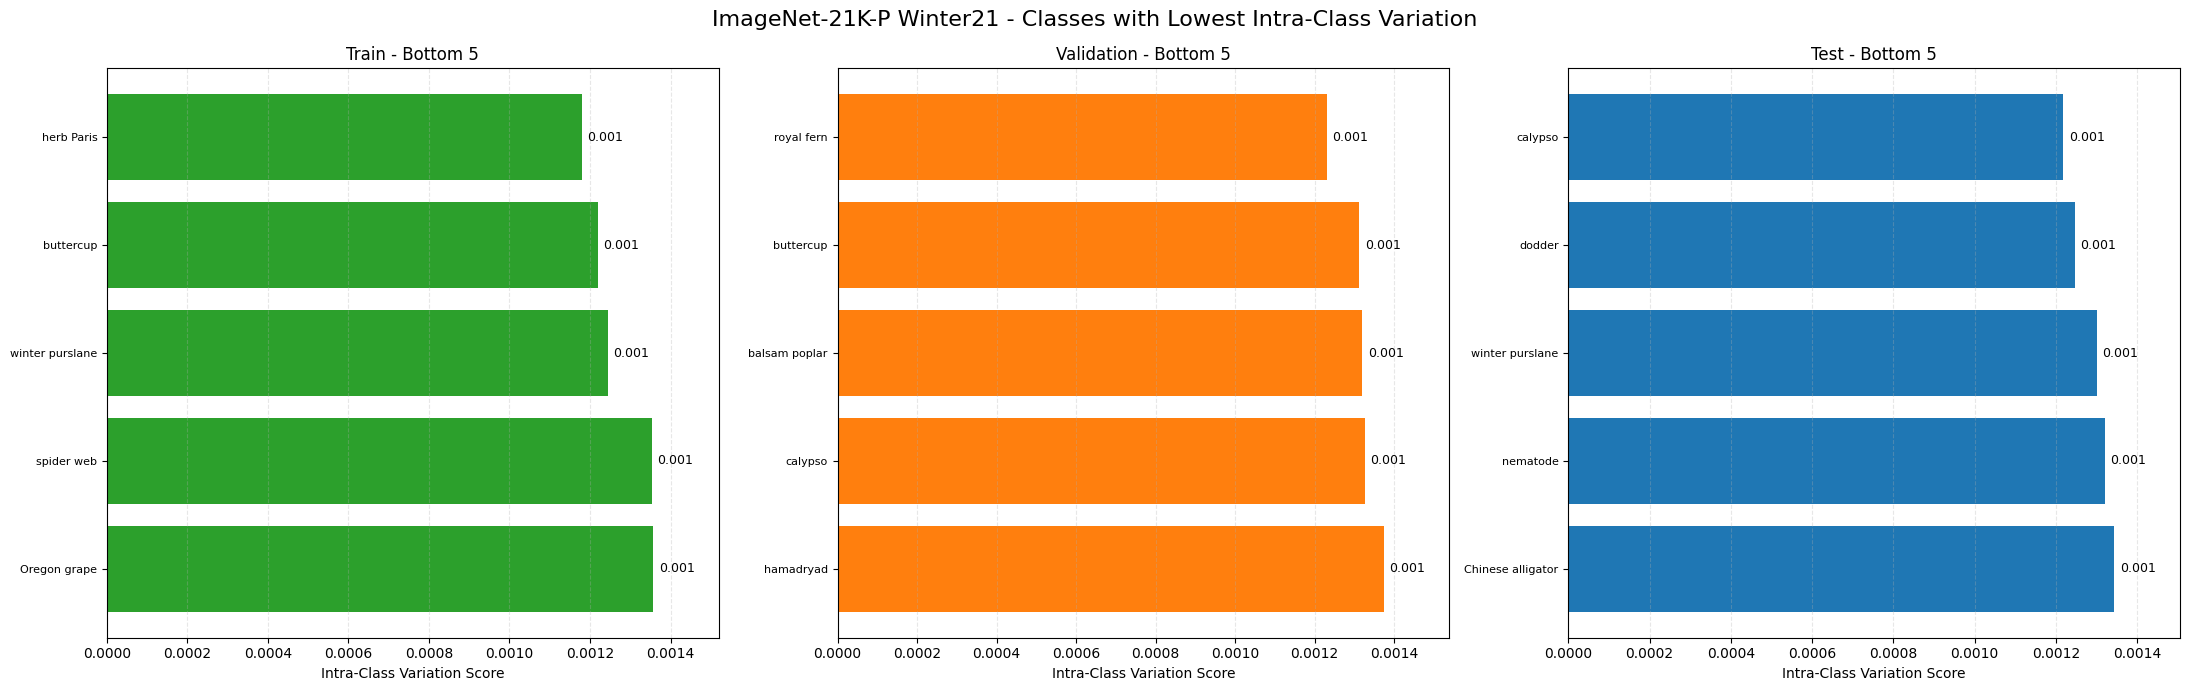

In [53]:
intra_class_variation_analysis.plot_least_variable_classes(
    intra_class_details,
    bottom_n=5,
)

#### 17. Inter-Class Variation Analysis

In [54]:
import src.eda.class_variation.inter_class_variation_analysis as inter_class_variation_analysis

In [56]:
inter_class_stats, inter_class_details = (
    inter_class_variation_analysis.inter_class_variation_analysis(
        dataset_list=dataset_list,
        max_classes=200,
        max_images_per_class=50,
        min_images_per_class=2,
        feature_size=32,
        seed=42,
    )
)

inter_class_stats

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/200 [00:00<?, ?it/s]

Train pairs:   0%|          | 0/19900 [00:00<?, ?it/s]

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

Validation pairs:   0%|          | 0/19900 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

Validation pairs:   0%|          | 0/19900 [00:00<?, ?it/s]

Test:   0%|          | 0/200 [00:00<?, ?it/s]

Test pairs:   0%|          | 0/19900 [00:00<?, ?it/s]

,Dataset,Split,Label Status,Classes Available,Classes Analyzed,Images Analyzed,Class Pairs,Mean Inter-Class Distance,Median Inter-Class Distance,Std Inter-Class Distance,Min Inter-Class Distance,Max Inter-Class Distance,Status
0,tiny_imagenet,Train,Labelled,200,200,10000,19900,0.001848,0.001057,0.001722,0.000347,0.008705,Analyzed
1,tiny_imagenet,Validation,Labelled,200,200,9993,19900,0.001529,0.000927,0.002102,0.000339,0.017477,Analyzed
2,tiny_imagenet,Test,Unlabelled,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,200,200,10000,19900,0.003114,0.001565,0.003147,0.000263,0.016015,Analyzed
4,imagenet21k_p,Validation,Labelled,200,200,4958,19900,0.00282,0.001429,0.003799,0.000399,0.021982,Analyzed
5,imagenet21k_p,Test,Labelled,200,200,4977,19900,0.002801,0.001464,0.003509,0.000375,0.017538,Analyzed


##### Closest classes overall

In [57]:
inter_class_details.sort_values(
    "Inter-Class Distance",
    ascending=True,
).head(5)

,Dataset,Split,Class A ID,Class A Name,Class A Images,Class B ID,Class B Name,Class B Images,Inter-Class Distance
58982,imagenet21k_p,Train,161,marsh marigold,50,185,bird's foot trefoil,50,0.000263
59186,imagenet21k_p,Train,167,winter purslane,50,182,herb Paris,50,0.000268
43065,imagenet21k_p,Train,17,calf,50,36,hawkmoth,50,0.000273
58905,imagenet21k_p,Train,159,Oregon grape,50,185,bird's foot trefoil,50,0.000293
40596,imagenet21k_p,Train,4,white-crowned sparrow,50,11,Chinese alligator,50,0.000296


##### Most separated classes

In [58]:
inter_class_details.sort_values(
    "Inter-Class Distance",
    ascending=False,
).head(5)

,Dataset,Split,Class A ID,Class A Name,Class A Images,Class B ID,Class B Name,Class B Images,Inter-Class Distance
71968,imagenet21k_p,Validation,75,dogsled,25,194,royal fern,25,0.021982
71963,imagenet21k_p,Validation,75,dogsled,25,189,balsam poplar,25,0.021945
71934,imagenet21k_p,Validation,75,dogsled,25,160,buttercup,24,0.021942
71948,imagenet21k_p,Validation,75,dogsled,25,174,calypso,25,0.021937
71951,imagenet21k_p,Validation,75,dogsled,25,177,cordgrass,25,0.021933


##### Distribution plots

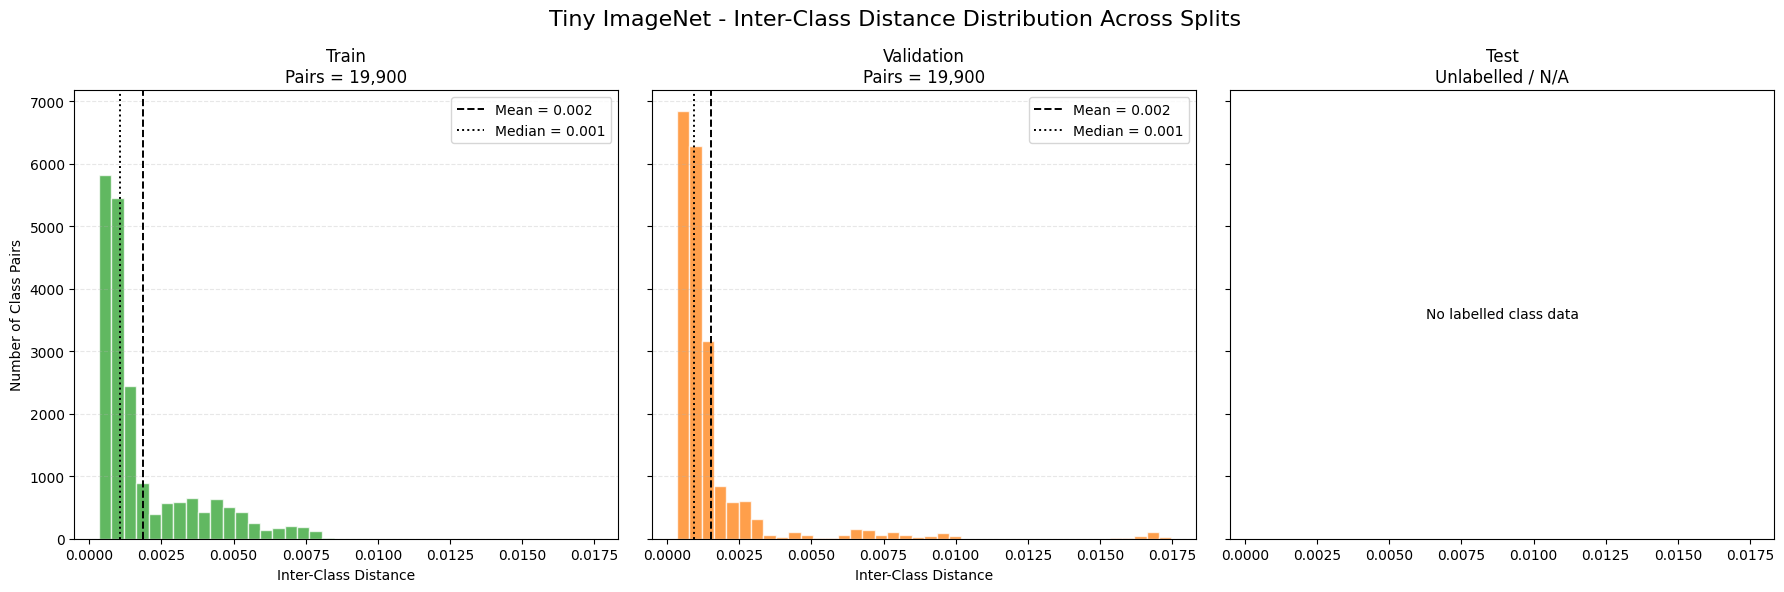

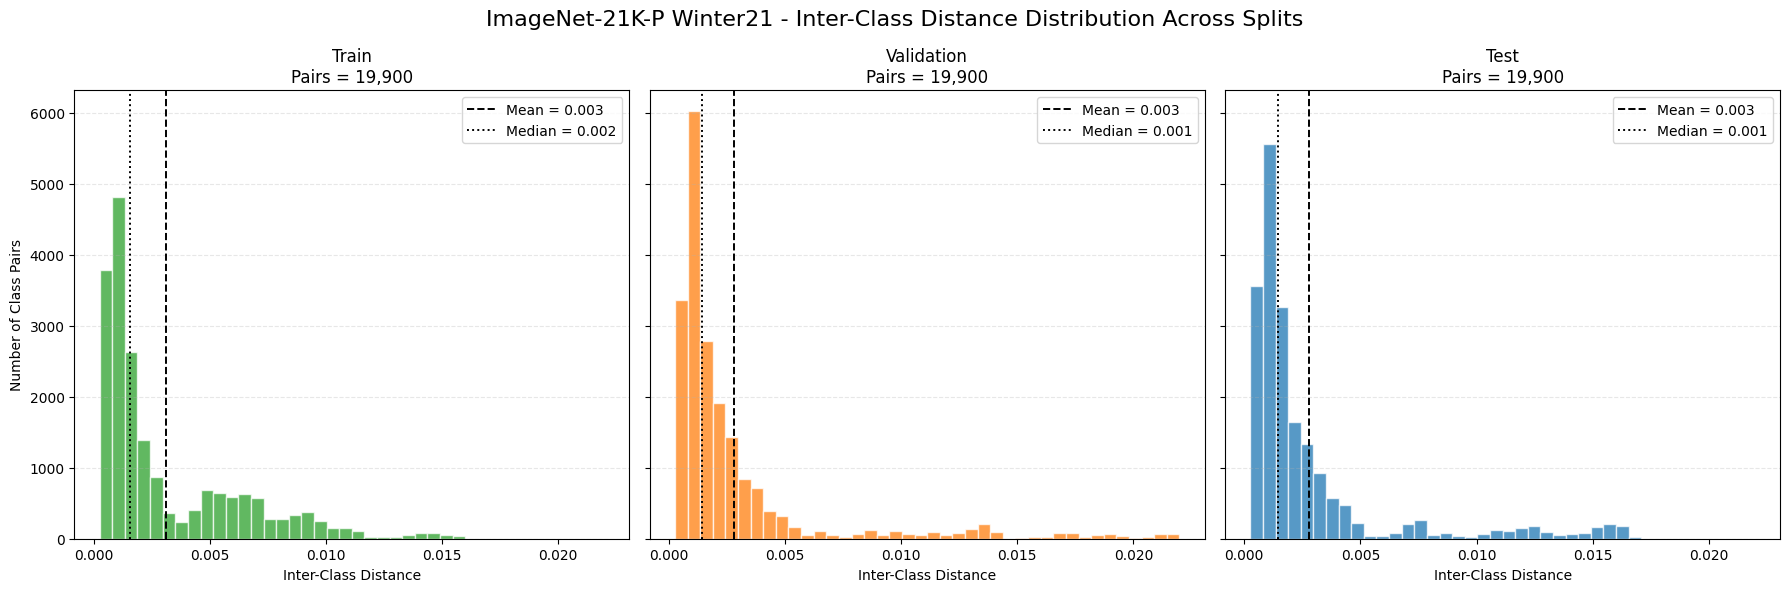

In [59]:
inter_class_variation_analysis.plot_inter_class_distribution(
    inter_class_details
)

##### Most visually similar class pairs

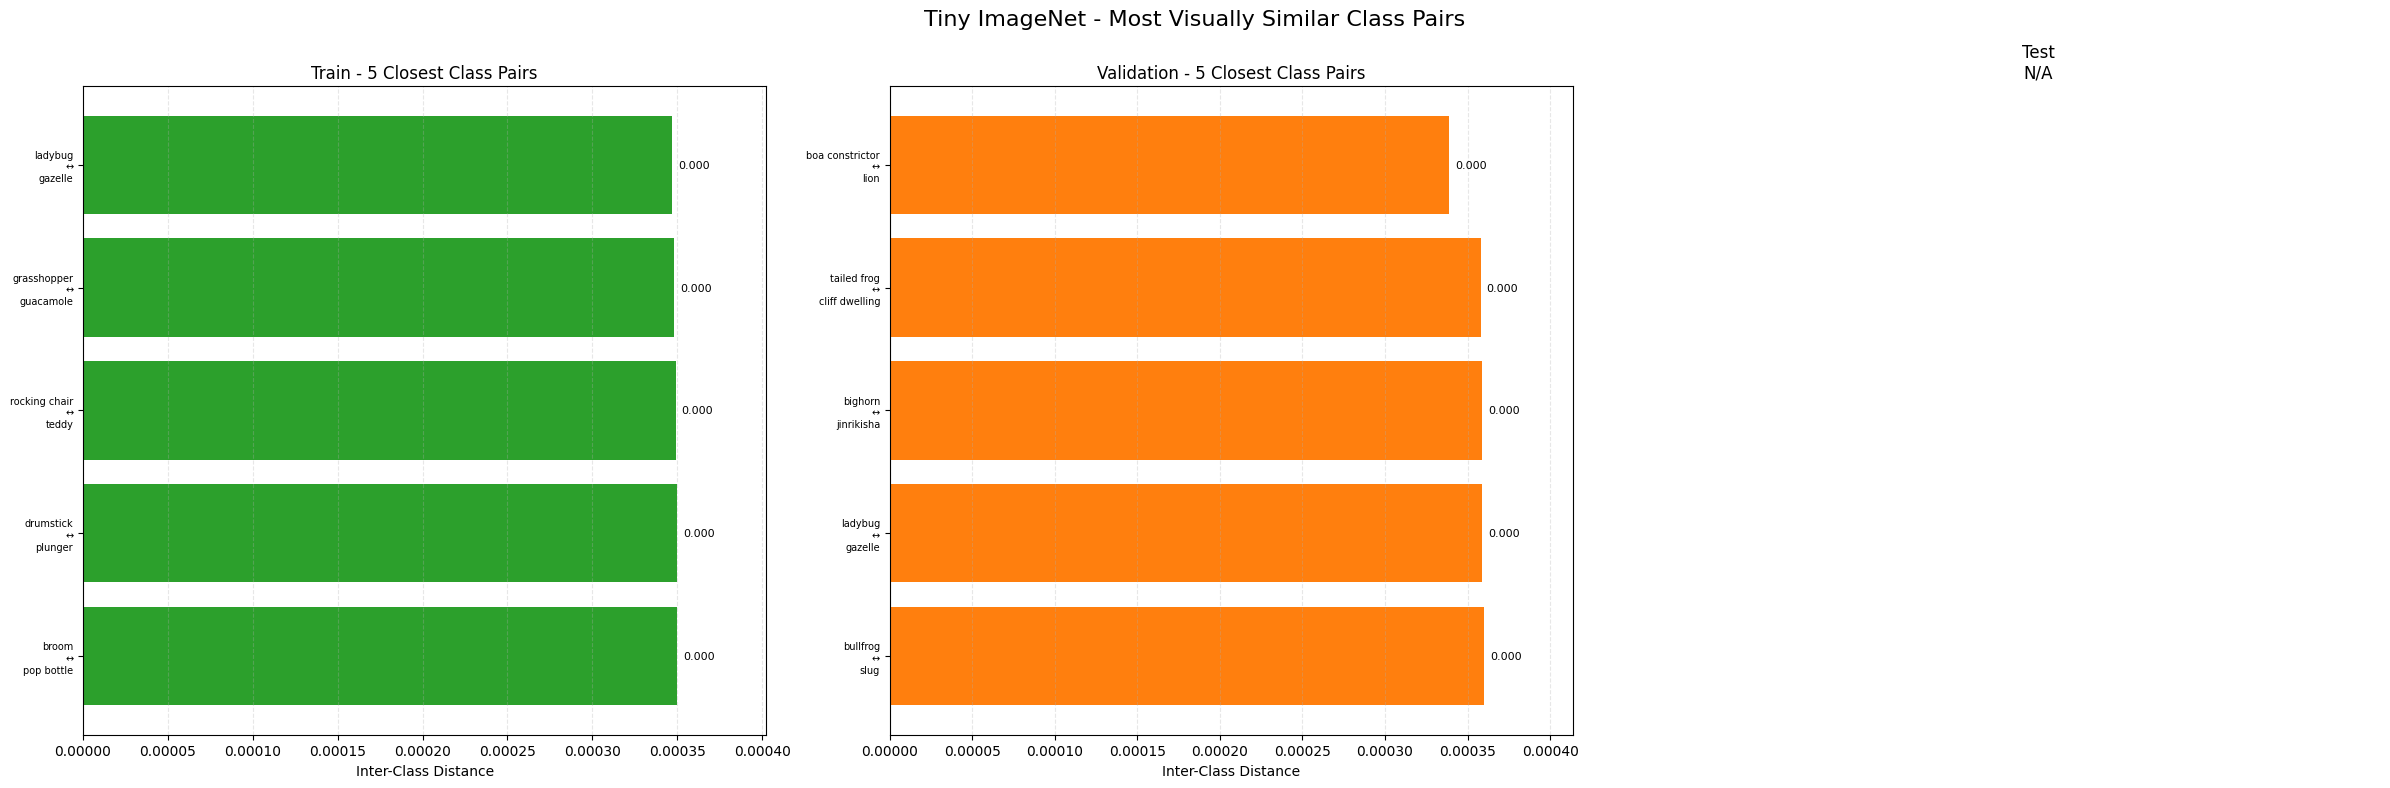

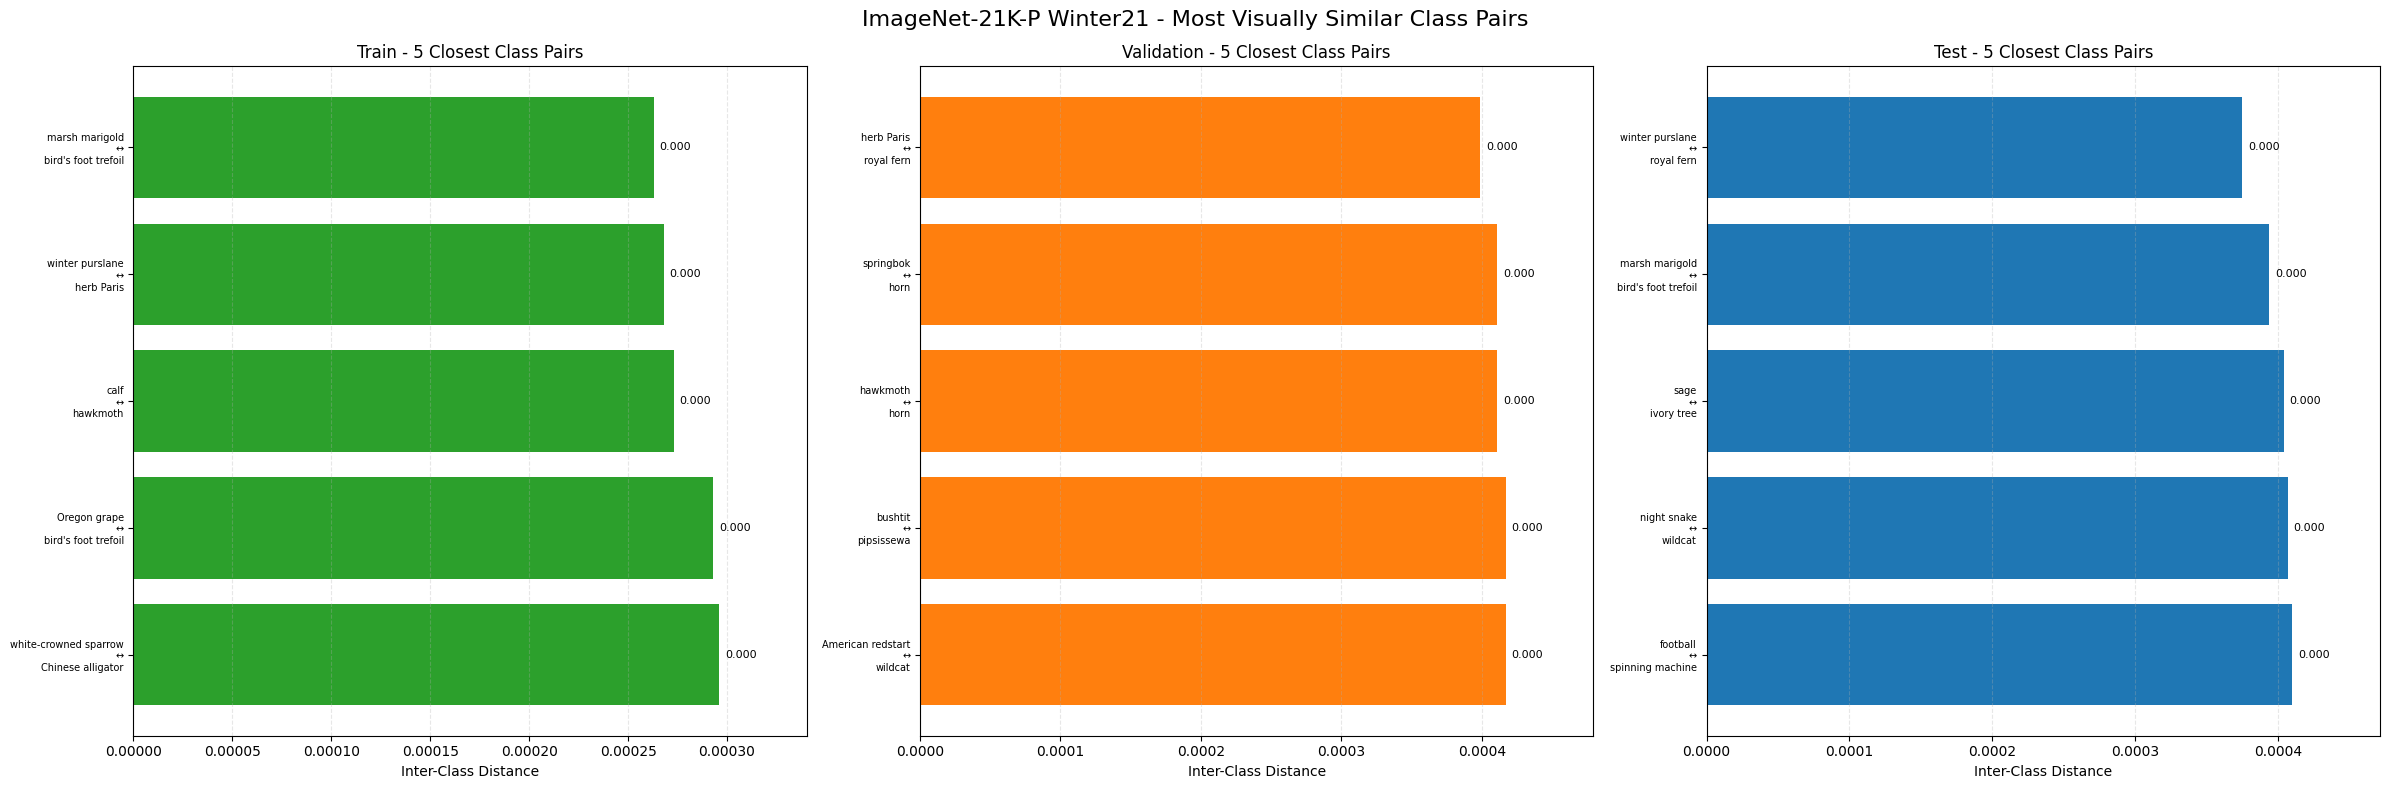

In [60]:
inter_class_variation_analysis.plot_closest_class_pairs(
    inter_class_details,
    top_n=5,
    min_plot_images=10,
)

##### Most visually separated class pairs

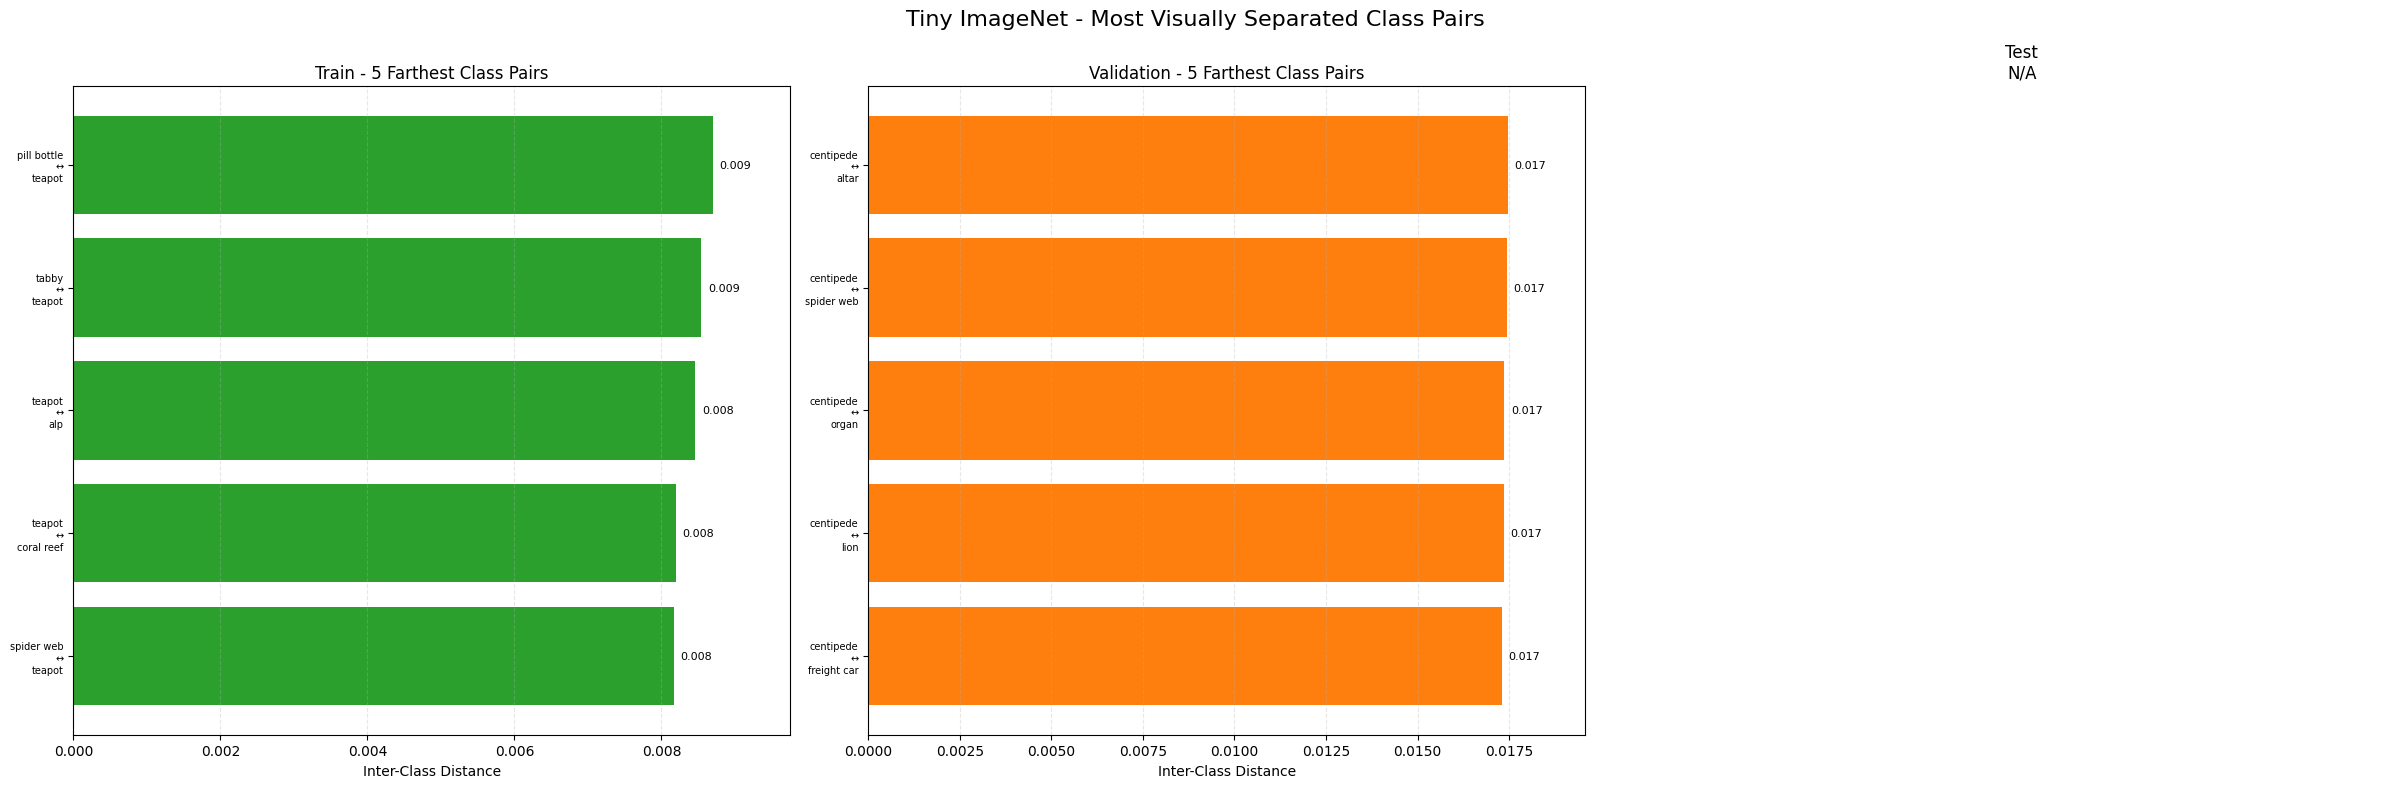

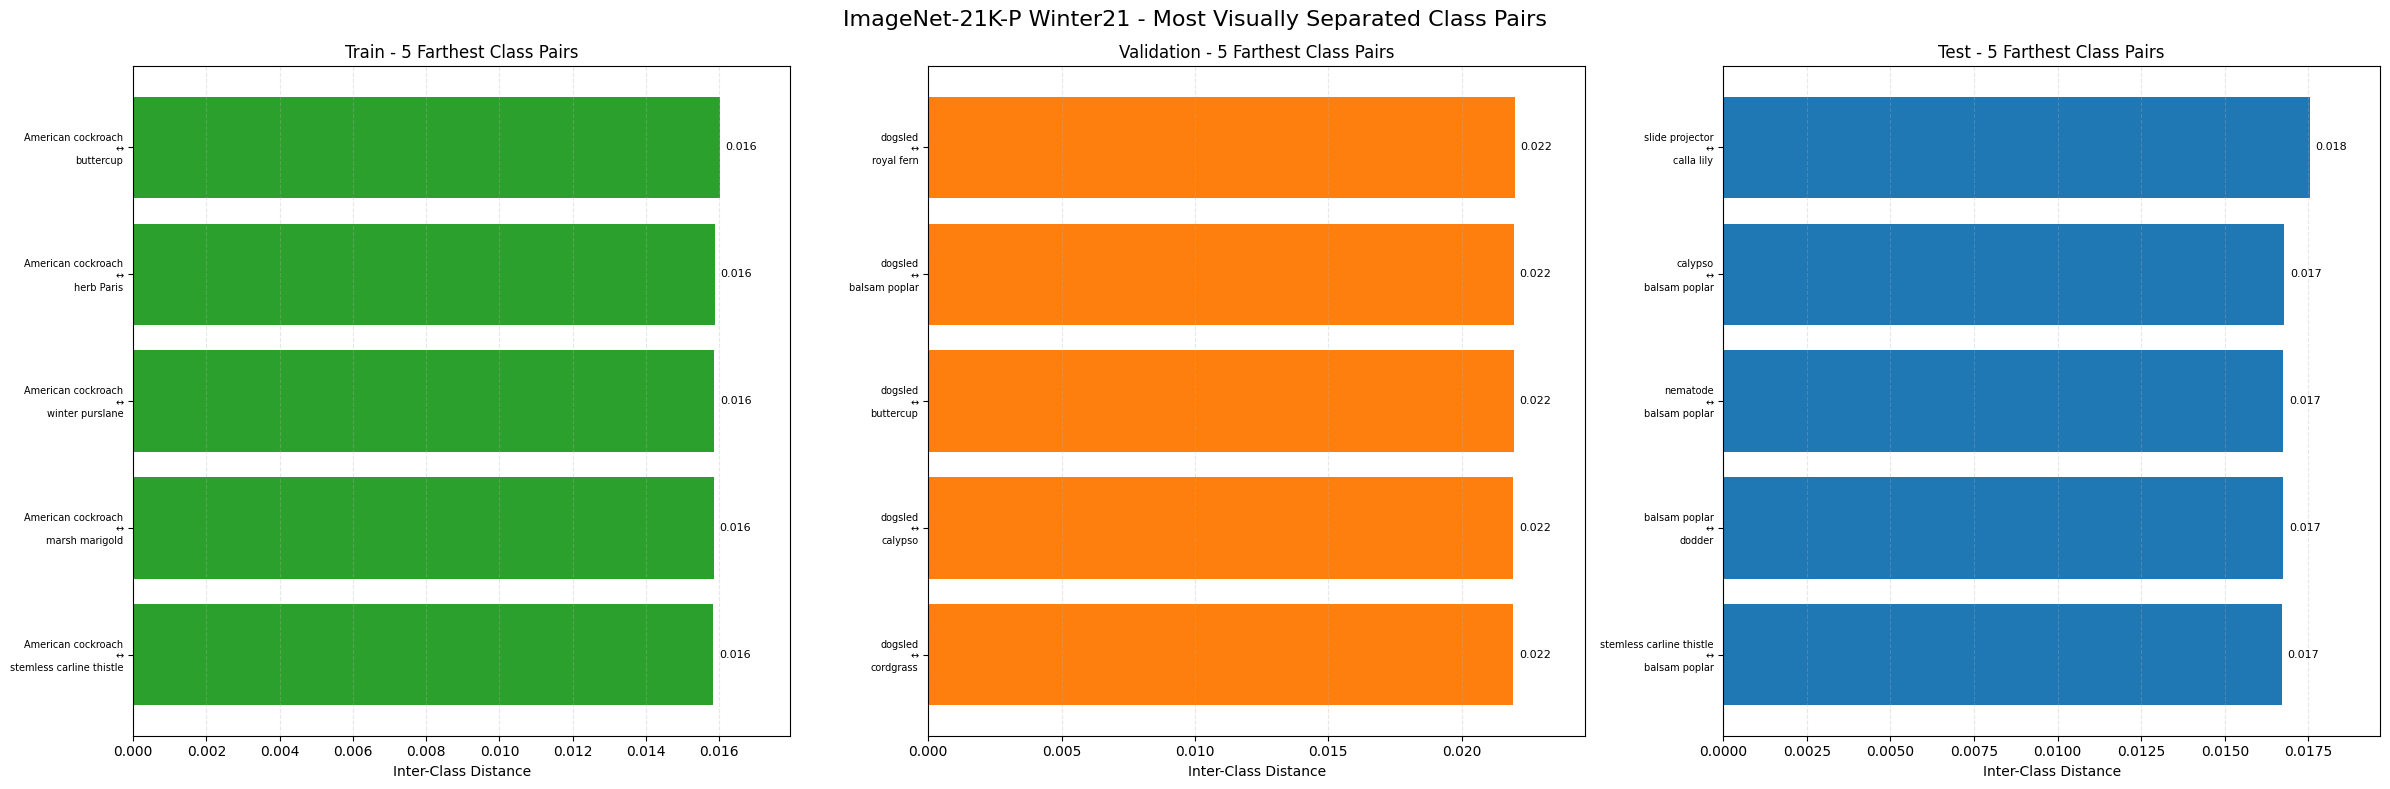

In [61]:
inter_class_variation_analysis.plot_farthest_class_pairs(
    inter_class_details,
    top_n=5,
    min_plot_images=10,
)

## Dataset Difficulty

#### 18. Dataset Difficulty Comparison

In [62]:
import src.eda.dataset_difficulty.dataset_difficulty_analysis as dataset_difficulty_analysis

In [63]:
difficulty_stats = (
    dataset_difficulty_analysis.dataset_difficulty_analysis(
        class_distribution,
        image_dimensions,
        intra_class_stats,
        inter_class_stats,
        duplicate_stats,
    )
)

difficulty_stats

Datasets:   0%|          | 0/2 [00:00<?, ?it/s]

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]

imagenet21k_p splits:   0%|          | 0/3 [00:00<?, ?it/s]

Structural ranking:   0%|          | 0/3 [00:00<?, ?it/s]

,Dataset,Split,Label Status,Total Images,Classes,Imbalance Ratio,Class CV,Unique Resolutions,Resolution Diversity (%),Mean Intra-Class Variation,Mean Inter-Class Distance,Low-Level Structural Difficulty Ratio,Relative Structural Rank,Duplicate (%),Dataset Leakage Groups,Dataset Leakage Status,Status
0,tiny_imagenet,Train,Labelled,99953,200.0,1.010,0.001,1,0.0010,0.003314,0.001848,1.793290,1,0.0090,1,Leakage Detected,Analyzed
1,tiny_imagenet,Validation,Labelled,9993,200.0,1.042,0.004,1,0.0100,0.002952,0.001529,1.930674,1,0.0100,1,Leakage Detected,Analyzed
2,tiny_imagenet,Test,Unlabelled,9988,NaN,NaN,NaN,1,0.0100,NaN,NaN,NaN,<NA>,0.0000,1,Leakage Detected,N/A
3,imagenet21k_p,Train,Labelled,201319,200.0,5.547,0.338,1,0.0005,0.004108,0.003114,1.319204,2,0.0045,1,Leakage Detected,Analyzed
4,imagenet21k_p,Validation,Labelled,4958,200.0,1.923,0.042,1,0.0202,0.003630,0.002820,1.287234,2,0.0000,1,Leakage Detected,Analyzed
5,imagenet21k_p,Test,Labelled,4977,200.0,1.389,0.025,1,0.0201,0.003547,0.002801,1.266333,1,0.0000,1,Leakage Detected,Analyzed


###### Training-set comparison

In [64]:
train_difficulty_summary = (
    dataset_difficulty_analysis.get_train_difficulty_summary(
        difficulty_stats
    )
)

train_difficulty_summary

,Dataset,Total Images,Classes,Imbalance Ratio,Class CV,Unique Resolutions,Resolution Diversity (%),Mean Intra-Class Variation,Mean Inter-Class Distance,Low-Level Structural Difficulty Ratio,Relative Structural Rank,Duplicate (%),Dataset Leakage Groups,Dataset Leakage Status
0,tiny_imagenet,99953,200.0,1.010,0.001,1,0.0010,0.003314,0.001848,1.793290,1,0.0090,1,Leakage Detected
1,imagenet21k_p,201319,200.0,5.547,0.338,1,0.0005,0.004108,0.003114,1.319204,2,0.0045,1,Leakage Detected


##### Difficulty map

Structural difficulty plots:   0%|          | 0/3 [00:00<?, ?it/s]

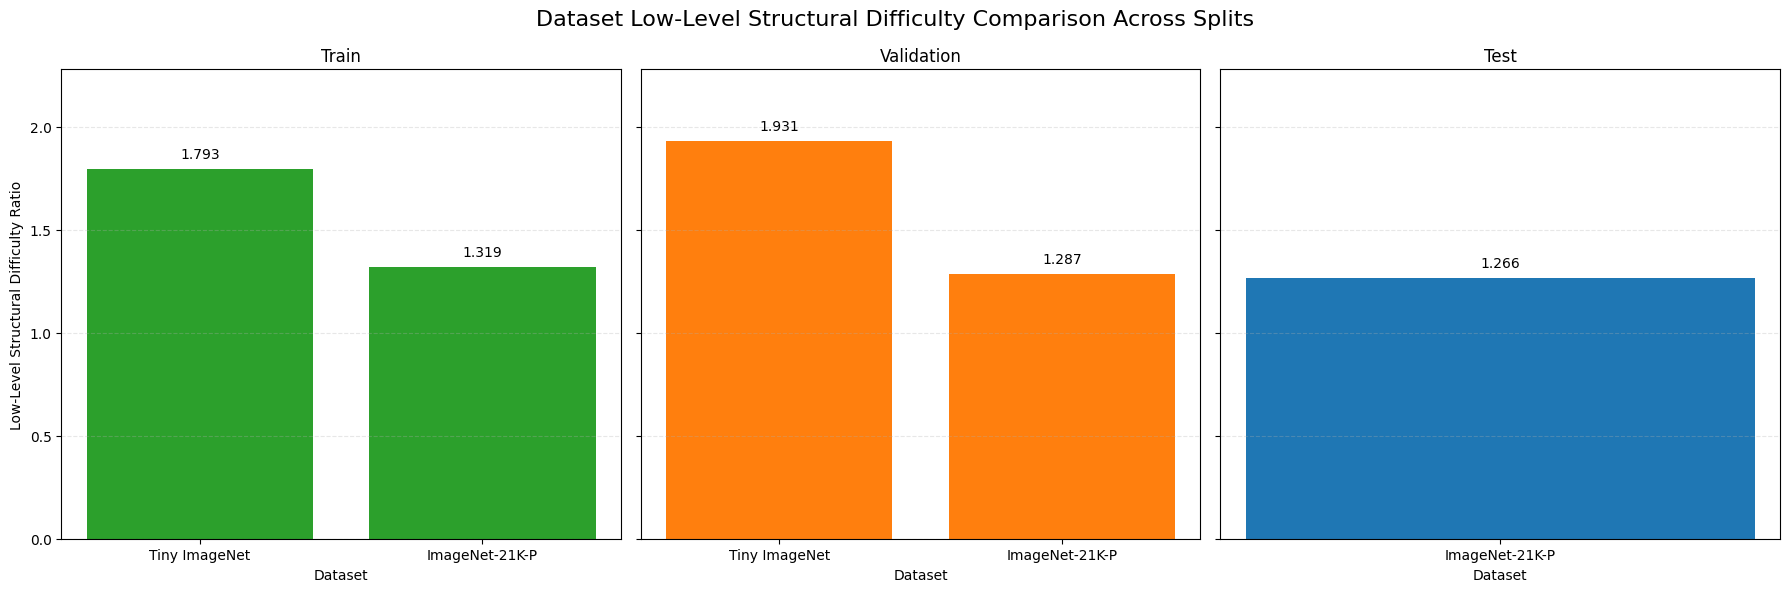

In [65]:
dataset_difficulty_analysis.plot_structural_difficulty(
    difficulty_stats
)

##### Class imbalance graph

Class imbalance plots:   0%|          | 0/3 [00:00<?, ?it/s]

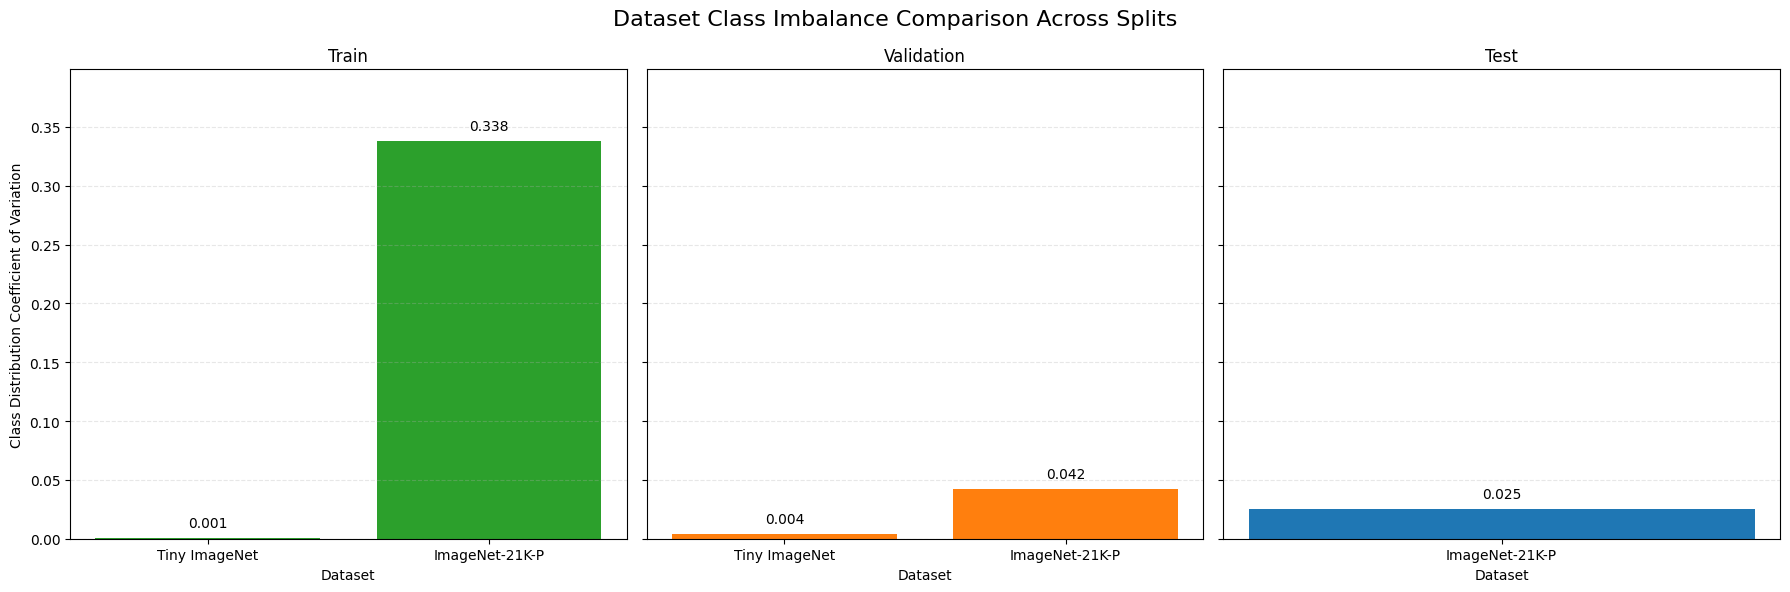

In [66]:
dataset_difficulty_analysis.plot_class_imbalance_difficulty(
    difficulty_stats
)

##### Resolution diversity graph

Resolution diversity plots:   0%|          | 0/3 [00:00<?, ?it/s]

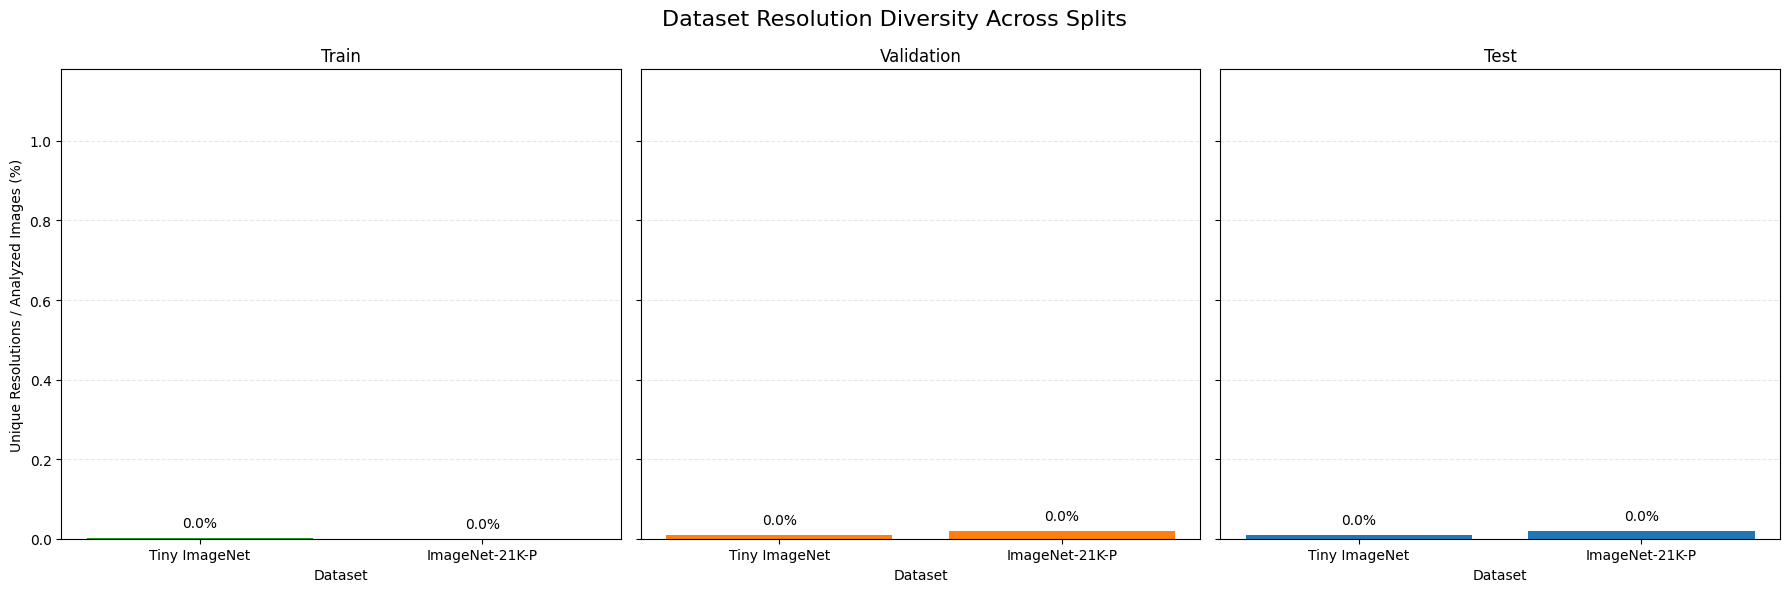

In [67]:
dataset_difficulty_analysis.plot_resolution_diversity(
    difficulty_stats
)